In [194]:
import cv2, time
import os
import matplotlib.pyplot as plt

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from utils import tensor_to_video as t2v
from utils import dzida, make_rotating_rect_tensor

[DEBUG frame 0] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 0] bev.sum() = 5136975
[DEBUG frame 299] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 299] bev.sum() = 5245605
[DEBUG frame 0] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 0] bev.sum() = 4535430
[DEBUG frame 299] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 299] bev.sum() = 4361265


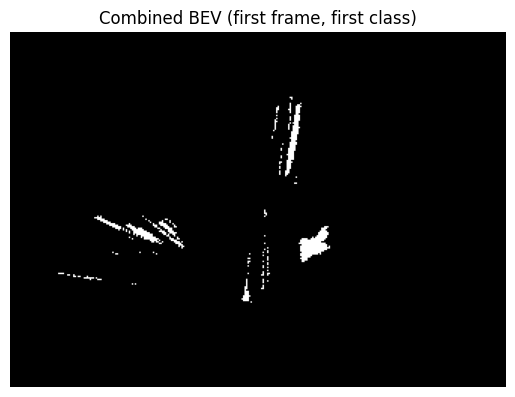

In [23]:
import numpy as np
import io
import cv2
from dataclasses import dataclass
import matplotlib.pyplot as plt
import os

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src






def _build_intrinsics(W, H, K0=None, K0_size=None, fx=1100.0, fy=None):
    if K0 is not None and K0_size is not None:
        W0, H0 = K0_size
        sx, sy = W / float(W0), H / float(H0)
        return np.array([
            [K0[0,0]*sx, 0.0,           K0[0,2]*sx],
            [0.0,        K0[1,1]*sy,    K0[1,2]*sy],
            [0.0,        0.0,           1.0]
        ], dtype=np.float64)
    
    if fy is None:
        fy = fx
    cx, cy = W / 2.0, H / 2.0
    return np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)
# REPLACE the strict converters with robust ones

def indices_to_onehot_safe(
    idx2d: np.ndarray,
    valid_ids: list[int] | range = range(1, 13),  # labels you want to keep
    out_num_classes: int = 12,                     # K channels in output
    id_map: dict[int, int] | None = None,         # optional raw->target map (1..K)
    background_ids: tuple[int, ...] = (0,),       # labels to ignore
    dtype=np.uint8
) -> np.ndarray:
    """
    Robust 2D indices -> one-hot (H,W,K):
      - Keeps only valid_ids (or those present in id_map)
      - Ignores labels in background_ids and anything not in valid_ids
      - If id_map is provided, it can merge multiple raw labels into one channel
    """
    if idx2d.ndim != 2:
        raise ValueError(f"idx2d must be 2D, got shape {idx2d.shape}")

    h, w = idx2d.shape
    onehot = np.zeros((h, w, out_num_classes), dtype=dtype)

    if id_map:
        for raw_id, class_id in id_map.items():
            if not (1 <= class_id <= out_num_classes):
                raise ValueError(f"class_id {class_id} out of 1..{out_num_classes}")
            m = (idx2d == raw_id)
            if m.any():
                onehot[..., class_id - 1] |= m.astype(dtype)
        return onehot

    keep = set(valid_ids)
    ignore = set(background_ids)
    # Only light up channels for raw ids we care about (1..K by default)
    for raw_id in np.unique(idx2d):
        if raw_id in ignore:
            continue
        if raw_id in keep and 1 <= raw_id <= out_num_classes:
            m = (idx2d == raw_id)
            if m.any():
                onehot[..., raw_id - 1] |= m.astype(dtype)
        # else: silently ignore stray labels (e.g., 13+)
    return onehot


def stack_indices_to_onehot_safe(
    idx_stack: np.ndarray | list[np.ndarray],
    valid_ids: list[int] | range = range(1, 13),
    out_num_classes: int = 12,
    id_map: dict[int, int] | None = None,
    background_ids: tuple[int, ...] = (0,),
    dtype=np.uint8
) -> np.ndarray:
    """
    Robust (T,H,W) or list[(H,W)] -> (T,H,W,K) one-hot, ignoring stray labels.
    """
    if isinstance(idx_stack, np.ndarray):
        if idx_stack.ndim != 3:
            raise ValueError(f"idx_stack must be (T,H,W), got {idx_stack.shape}")
        frames = [idx_stack[t] for t in range(idx_stack.shape[0])]
    else:
        frames = idx_stack
        if not frames:
            raise ValueError("idx_stack is empty")

    oh_list = [
        indices_to_onehot_safe(
            f,
            valid_ids=valid_ids,
            out_num_classes=out_num_classes,
            id_map=id_map,
            background_ids=background_ids,
            dtype=dtype,
        )
        for f in frames
    ]
    return np.stack(oh_list, axis=0)  # (T,H,W,K)

def video_to_bev_tensor(
    video_tensor,
    segmented_video,
    n_frames=None,
    *,
    height_m=1.4,
    pitch_deg_down=6.0,
    roll_deg=0.0,
    yaw_deg=0.0,
    K0=None,
    K0_size=None,
    fx=1100.0,
    fy=None,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False
):
    N_all = min(len(video_tensor), len(segmented_video))
    N = N_all if n_frames is None else min(n_frames, N_all)

    H, W = segmented_video[0].shape[:2]
    K = _build_intrinsics(W, H, K0=K0, K0_size=K0_size, fx=fx, fy=fy)

    roll = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)
    yaw = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m,
        roll=roll,
        pitch=pitch,
        yaw=yaw
    )

    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )

    W_out, H_out = grid.size
    bev_tensor = np.zeros((H_out, W_out, N), dtype=np.uint8)

    for i in range(N):
        mask01 = (segmented_video[i] == 0).astype(np.uint8)
        bev = projector.warp_calibrated(mask01=mask01, grid=grid)
        bev_tensor[:, :, i] = bev

        if debug and (i == 0 or (i + 1) == N):
            H_pg, S = projector.H_pg, grid.scaling_matrix()
            A = H_pg @ S
            dst = np.array([[0,0,1],[W_out-1,0,1],[W_out-1,H_out-1,1],[0,H_out-1,1]], dtype=np.float64).T
            img_corners = (A @ dst); img_corners = (img_corners[:2]/img_corners[2]).T
            print(f"[DEBUG frame {i}] BEV corners -> image:\n", img_corners)
            print(f"[DEBUG frame {i}] bev.sum() = {bev.sum()}")

    return bev_tensor, projector, grid


def indices_to_onehot(idx2d: np.ndarray,
                      num_classes: int = 12,
                      class_offset: int = 1,
                      dtype=np.uint8) -> np.ndarray:
    """
    Convert a 2D index image with class IDs in [class_offset, class_offset+num_classes-1]
    into a one-hot tensor of shape (H, W, num_classes).
    """
    if idx2d.ndim != 2:
        raise ValueError(f"idx2d must be 2D, got shape {idx2d.shape}")
    h, w = idx2d.shape
    idx_norm = (idx2d.astype(np.int32) - class_offset)
    if (idx_norm.min() < 0) or (idx_norm.max() >= num_classes):
        raise ValueError(f"indices out of range after offset: min={idx_norm.min()}, max={idx_norm.max()}, K={num_classes}")
    classes = np.arange(num_classes, dtype=np.int32).reshape(1, 1, num_classes)
    idx_exp = idx_norm[..., None]
    onehot_bool = (idx_exp == classes)
    return onehot_bool.astype(dtype)

def stack_indices_to_onehot(idx_list,
                            num_classes: int = 12,
                            class_offset: int = 1,
                            dtype=np.uint8) -> np.ndarray:
    """
    Convert a list/iterator of 2D index frames into a 4D one-hot video tensor.
    """
    onehots = [indices_to_onehot(f, num_classes=num_classes, class_offset=class_offset, dtype=dtype)
               for f in idx_list]
    if not onehots:
        raise ValueError("idx_list is empty")
    return np.stack(onehots, axis=0)

def onehot_to_npy_bytes(onehot: np.ndarray) -> bytes:
    """
    Serialize a (H,W,K) or (T,H,W,K) one-hot tensor to .npy bytes.
    """
    buf = io.BytesIO()
    np.save(buf, onehot.astype(np.uint8, copy=False), allow_pickle=False)
    return buf.getvalue()

def npy_bytes_to_onehot(b: bytes) -> np.ndarray:
    """
    Load one-hot tensor from .npy bytes.
    Returns (H,W,K) or (T,H,W,K) depending on what was saved.
    """
    return np.load(io.BytesIO(b), allow_pickle=False)

def onehot_channel(onehot: np.ndarray,
                   class_index_original: int,
                   class_offset: int = 1,
                   squeeze_last: bool = True,
                   dtype=np.uint8) -> np.ndarray:
    """
    Extract one channel from one-hot where `class_index_original` is the original label id (e.g., 1..12).
    Accepts either (H,W,K) or (T,H,W,K). Returns (H,W) or (T,H,W) mask.
    """
    if onehot.ndim == 3:
        ch = class_index_original - class_offset
        if ch < 0 or ch >= onehot.shape[-1]:
            raise ValueError("class_index_original out of range")
        mask = onehot[..., ch]
        return mask.astype(dtype, copy=False) if squeeze_last else mask[..., None].astype(dtype, copy=False)
    elif onehot.ndim == 4:
        ch = class_index_original - class_offset
        if ch < 0 or ch >= onehot.shape[-1]:
            raise ValueError("class_index_original out of range")
        mask = onehot[..., ch]
        return mask.astype(dtype, copy=False) if squeeze_last else mask[..., None].astype(dtype, copy=False)
    else:
        raise ValueError(f"onehot must be 3D or 4D, got {onehot.shape}")

def onehot_to_binary_for_bev(onehot_frame: np.ndarray,
                             road_class_index_original: int,
                             class_offset: int = 1) -> np.ndarray:
    """
    Convert a (H,W,K) one-hot frame into a 2D binary mask (0/1) for the 'road' class.
    """
    mask = onehot_channel(onehot_frame, road_class_index_original, class_offset=class_offset,
                          squeeze_last=True, dtype=np.uint8)
    return mask

def npy_to_bev_tensor(
    path,
    n_frames=None,
    *,
    pitch_deg_down=6.0,
    height_m=1.4,
    fx=1100.0,
    fy=530,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False,
    class_index_original=1,   # which raw label is “road”
    num_classes=12,
    # class_offset is no longer used; kept for call-compatibility only
    class_offset=1
):
    """
    Loads `.npy` labels (either (T,H,W) with raw ids, or (T,H,W,K) one-hot).
    Robustly converts raw ids into one-hot (ignoring junk labels), extracts the
    desired class channel (default: road=1), projects to BEV over T frames.
    """
    assert os.path.exists(path), f"File not found: {path}"
    segmented_video = np.load(path)

    # Convert to one-hot robustly if needed
    if segmented_video.ndim == 3:
        # (T,H,W) of raw indices; ignore 0 and >num_classes by default
        onehot_video = stack_indices_to_onehot_safe(
            segmented_video,
            valid_ids=range(1, num_classes + 1),
            out_num_classes=num_classes,
            id_map=None,           # supply a dict if you need to merge remap classes
            background_ids=(0,),   # ignore label 0
            dtype=np.uint8
        )
    elif segmented_video.ndim == 4:
        # Already (T,H,W,K)
        onehot_video = segmented_video
        if onehot_video.shape[-1] < num_classes:
            # You can either raise or pad; we’ll raise to avoid silent misuse
            raise ValueError(
                f"Provided one-hot has K={onehot_video.shape[-1]} < num_classes={num_classes}"
            )
    else:
        raise ValueError(f"Unexpected shape for input npy: {segmented_video.shape}")

    T, H, W, K = onehot_video.shape
    if not (1 <= class_index_original <= K):
        raise ValueError(f"class_index_original={class_index_original} not in 1..{K}")

    # Extract desired class channel (H,W) per frame: (T,H,W) 0/1
    mask_video = onehot_video[..., class_index_original - 1].astype(np.uint8)

    # Dummy RGB video (unused by BEV math, but keeps API consistent)
    dummy_video = np.zeros((T, H, W, 3), dtype=np.uint8)

    return video_to_bev_tensor(
        video_tensor=dummy_video,
        segmented_video=mask_video,     # (T,H,W) 0/1
        n_frames=n_frames,
        height_m=height_m,
        pitch_deg_down=pitch_deg_down,
        fx=fx,
        fy=fy,
        meters_per_pixel=meters_per_pixel,
        forward_range=forward_range,
        lateral_range=lateral_range,
        debug=debug
    )


# Process directly from file path:





def rotate_shift_sum(img1, img2, angle_deg=10.0, hor_shift_px=10):
    """
    Rotate img1 by +angle and shift LEFT, rotate img2 by -angle and shift RIGHT.
    Sum the two results on the smallest canvas that fits both, using 0-padding.

    Returns:
        output: np.ndarray of dtype float32 or uint8 (based on input),
                shape (H_out, W_out, C) or (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Both images must be same size"
    H, W = img1.shape[:2]
    is_color = img1.ndim == 3
    C = img1.shape[2] if is_color else 1

    # Convert to float32 for accumulation
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    # Rotation matrices around center
    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    # Horizontal shift: img1 left, img2 right
    M1[0, 2] -= hor_shift_px
    M2[0, 2] += hor_shift_px

    # Compute canvas size
    def transform_corners(M):
        corners = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        corners_h = np.hstack([corners, ones])
        transformed = (M @ corners_h.T).T
        return transformed

    corners1 = transform_corners(M1)
    corners2 = transform_corners(M2)
    all_corners = np.vstack([corners1, corners2])

    min_xy = np.floor(all_corners.min(axis=0)).astype(int)
    max_xy = np.ceil(all_corners.max(axis=0)).astype(int)
    out_W, out_H = (max_xy - min_xy)[0], (max_xy - min_xy)[1]

    shift_x, shift_y = -min_xy[0], -min_xy[1]
    M1[:, 2] += shift_x
    M2[:, 2] += shift_x
    M1[1, 2] += shift_y
    M2[1, 2] += shift_y

    # Warp both images
    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    warp1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    warp2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)

    # Sum the results
    summed = warp1 + warp2

    # Return in same dtype as input (clip if needed)
    if np.issubdtype(img1.dtype, np.integer):
        summed = np.clip(summed, 0, 255).astype(img1.dtype)
    return summed




def list_to_numpy_tensor(frames, axis=-1, dtype=None):
    """
    Convert a list of NumPy 2D arrays into a single 3D array (a 'tensor').
    axis=-1  -> shape (H, W, N)   # channels-last style
    axis=0   -> shape (N, H, W)   # batch-first style
    """
    if not frames:
        raise ValueError("frames list is empty")

    base_shape = frames[0].shape
    for i, f in enumerate(frames):
        if f.shape != base_shape:
            raise ValueError(f"All frames must have the same shape: "
                             f"frame 0 is {base_shape}, frame {i} is {f.shape}")
    if dtype is None:
        dtype = np.result_type(*[np.asarray(f).dtype for f in frames])

    stacked = np.stack([np.asarray(f, dtype=dtype) for f in frames], axis=axis)
    return stacked





current_image_path = "1754410876"

#"/workspace/test_results/cam2_1754590241.npy

path = "/workspace/test_results/cam1_"+current_image_path+".npy"
bev_tensor1, projector1, grid1 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=300,
    fy=int(530/380*200),
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)
path = "/workspace/test_results/cam2_"+current_image_path+".npy"
bev_tensor2, projector2, grid2 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=380.0,
    fy=530,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)


bev_cal_tensor = 0
# Shape: (H_bev, W_bev, N)
fps = 12  # Set your desired frame rate
N = 300  # Number of frames

# Generate one combined frame to determine size
# Create the video writer

# Write each frame
combined_list = []
for i in range(N):
    combined = rotate_shift_sum(np.int8(bev_tensor2[:, :, i] / 255), np.int8(bev_tensor1[:, :, i] / 255), angle_deg = -35, hor_shift_px=-40)
    combined_list.append(combined)


tensor_hwn = list_to_numpy_tensor(combined_list, axis=-1, dtype=np.uint8)
import numpy as np
import cv2

def dilate_erode_blur_slice(
    image: np.ndarray, 
    kernel_size: int = 5,     
    blur_ksize: int = 7,
    blur_sigma: float = 1.0
    ) -> np.ndarray:
    """
    Performs dilation followed by erosion (closing) on the slice tensor_hwn[:, :, 50].

    Parameters:
        tensor_hwn (np.ndarray): Input tensor of shape (H, W, N)
        kernel_size (int): Size of the square kernel (default: 5)

    Returns:
        np.ndarray: Closed (dilated + eroded) version of slice [:, :, 50]
    """

    img = image.astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    
    closed = cv2.erode(img, kernel)
    dilated = cv2.dilate(closed, kernel)

    
    blurred = cv2.GaussianBlur(dilated, (blur_ksize, blur_ksize), blur_sigma)

    

    return blurred

denoised = dilate_erode_blur_slice(tensor_hwn, kernel_size=4, blur_sigma=6, blur_ksize=11)
#help()
plt.imshow(dilate_erode_blur_slice(tensor_hwn, kernel_size=4, blur_sigma=6, blur_ksize=11)[:, :, 10])

def bev_project_onehot_video(
    onehot_video: np.ndarray,        # (T, H, W, K), values in {0,1} or {0,255}
    *,
    height_m: float = 1.4,
    pitch_deg_down: float = 6.0,
    roll_deg: float = 0.0,
    yaw_deg: float = 0.0,
    K0=None,
    K0_size=None,
    fx: float = 1100.0,
    fy: float | None = None,
    meters_per_pixel: float = 0.10,
    forward_range: tuple[float, float] = (0.5, 40.0),
    lateral_range: tuple[float, float] = (-8.0, 8.0),
    binarize_threshold: int = 127,   # used if input channels are 0/255
) -> tuple[np.ndarray, BEVProjector, BEVGrid]:
    """
    Returns (bev_onehot, projector, grid) where bev_onehot is (T, H_bev, W_bev, K) in {0,1}.
    """
    assert onehot_video.ndim == 4, f"expected (T,H,W,K), got {onehot_video.shape}"
    T, H, W, K = onehot_video.shape

    # Build intrinsics
    Kcam = _build_intrinsics(W, H, K0=K0, K0_size=K0_size, fx=fx, fy=fy)

    # Pose (convert degrees to radians; pitch "down" is negative)
    roll  = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)
    yaw   = np.deg2rad(yaw_deg)

    # Projector & grid
    projector = BEVProjector().set_intrinsics(Kcam).set_pose(
        height_m=height_m, roll=roll, pitch=pitch, yaw=yaw
    )
    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range,
    )

    # Precompute a single warp matrix M for SRC->DST to reuse for all frames/channels
    H_pg = projector._ground_to_image_homography()
    S = grid.scaling_matrix()
    M = np.linalg.inv(S) @ np.linalg.inv(H_pg)  # p_dst = M * p_img

    W_out, H_out = grid.size
    bev = np.zeros((T, H_out, W_out, K), dtype=np.uint8)

    # Project every class channel for every frame
    for t in range(T):
        frame_oh = onehot_video[t]                   # (H,W,K)
        # Ensure channel data are 0/255 uint8 for cv2.warpPerspective NN
        # (we'll convert back to 0/1 at the end)
        if frame_oh.dtype != np.uint8:
            frame_oh_u8 = (frame_oh.astype(np.uint8) * 255)
        else:
            # if already 0/1, scale to 0/255 to be robust to NN warps
            mx = frame_oh.max()
            frame_oh_u8 = frame_oh * (255 if mx <= 1 else 1)

        for k in range(K):
            src = frame_oh_u8[..., k]
            dst = cv2.warpPerspective(
                src, M, (W_out, H_out),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0
            )
            # back to 0/1
            bev[t, ..., k] = (dst > binarize_threshold).astype(np.uint8)

    return bev, projector, grid


def npy_to_bev_onehot(
    path: str,
    n_frames: int | None = None,
    *,
    pitch_deg_down: float = 6.0,
    height_m: float = 1.4,
    fx: float = 1100.0,
    fy: float = 530.0,
    meters_per_pixel: float = 0.10,
    forward_range: tuple[float, float] = (0.5, 40.0),
    lateral_range: tuple[float, float] = (-8.0, 8.0),
    num_classes: int = 12,
) -> tuple[np.ndarray, BEVProjector, BEVGrid]:
    """
    Loads labels from `.npy`:
      - If shape (T,H,W) with raw ids: converts robustly to one-hot (T,H,W,K)
      - If shape (T,H,W,K): uses as-is (validates K)
    Returns BEV one-hot video (T, H_bev, W_bev, K) with all classes.
    """
    assert os.path.exists(path), f"File not found: {path}"
    arr = np.load(path)

    # to one-hot video (T,H,W,K)
    if arr.ndim == 3:
        onehot_video = stack_indices_to_onehot_safe(
            arr,
            valid_ids=range(1, num_classes + 1),
            out_num_classes=num_classes,
            id_map=None,
            background_ids=(0,),
            dtype=np.uint8,
        )
    elif arr.ndim == 4:
        if arr.shape[-1] < num_classes:
            raise ValueError(f"input K={arr.shape[-1]} < num_classes={num_classes}")
        onehot_video = arr.astype(np.uint8)
    else:
        raise ValueError(f"Unexpected array shape: {arr.shape}")

    T = onehot_video.shape[0]
    if n_frames is not None:
        T = min(T, int(n_frames))
        onehot_video = onehot_video[:T]

    bev_oh, projector, grid = bev_project_onehot_video(
        onehot_video,
        height_m=height_m,
        pitch_deg_down=pitch_deg_down,
        roll_deg=0.0,
        yaw_deg=0.0,
        fx=fx,
        fy=fy,
        meters_per_pixel=meters_per_pixel,
        forward_range=forward_range,
        lateral_range=lateral_range,
    )
    return bev_oh, projector, grid   # (T, H_bev, W_bev, K)

# --- Example usage for two cameras (returns 4-D) ---

path1 = f"/workspace/test_results/cam1_{current_image_path}.npy"
path2 = f"/workspace/test_results/cam2_{current_image_path}.npy"

bev1, proj1, grid1 = npy_to_bev_onehot(
    path1, n_frames=300,
    pitch_deg_down=0.0, height_m=1.0, fx=300, fy=int(530/380*200),
    meters_per_pixel=0.20, forward_range=(0.5, 30.0), lateral_range=(-20.0, 20.0),
)   # bev1: (T, H_bev, W_bev, K)

bev2, proj2, grid2 = npy_to_bev_onehot(
    path2, n_frames=300,
    pitch_deg_down=0.0, height_m=1.0, fx=380.0, fy=530,
    meters_per_pixel=0.20, forward_range=(0.5, 30.0), lateral_range=(-20.0, 20.0),
)   # bev2: (T, H_bev, W_bev, K)

# Combine both cameras per class

def rotate_shift_sum_binary(mask_left: np.ndarray, mask_right: np.ndarray,
                            angle_deg: float, hor_shift_px: int) -> np.ndarray:
    # masks are 0/1 uint8, convert to 0/255 for warp sum, then back to 0/1
    out = rotate_shift_sum((mask_left*255).astype(np.uint8),
                           (mask_right*255).astype(np.uint8),
                           angle_deg=angle_deg, hor_shift_px=hor_shift_px)
    return (out > 127).astype(np.uint8)
















def rotate_shift_canvas_size(H, W, angle_deg, hor_shift_px):
    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0, 2] -= hor_shift_px
    M2[0, 2] += hor_shift_px

    def corners_after(M):
        corners = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        return (M @ np.hstack([corners, ones]).T).T

    all_c = np.vstack([corners_after(M1), corners_after(M2)])
    min_xy = np.floor(all_c.min(axis=0)).astype(int)
    max_xy = np.ceil(all_c.max(axis=0)).astype(int)

    out_W = int(max_xy[0] - min_xy[0])
    out_H = int(max_xy[1] - min_xy[1])
    shift_x = -int(min_xy[0])
    shift_y = -int(min_xy[1])
    return out_H, out_W, shift_x, shift_y

def rotate_shift_sum_binary_fixed(mask_left01, mask_right01,
                                  angle_deg, hor_shift_px,
                                  out_H, out_W, shift_x, shift_y):
    # inputs are binary {0,1}; convert to 0..255 for warp
    L = (mask_left01.astype(np.uint8) * 255)
    R = (mask_right01.astype(np.uint8) * 255)

    H, W = L.shape[:2]
    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0, 2] -= hor_shift_px; M2[0, 2] += hor_shift_px
    M1[0, 2] += shift_x;      M2[0, 2] += shift_x
    M1[1, 2] += shift_y;      M2[1, 2] += shift_y

    # use NEAREST for binary masks
    warp1 = cv2.warpAffine(L, M1, (out_W, out_H), flags=cv2.INTER_NEAREST, borderValue=0)
    warp2 = cv2.warpAffine(R, M2, (out_W, out_H), flags=cv2.INTER_NEAREST, borderValue=0)

    summed = cv2.add(warp1, warp2)
    return (summed > 127).astype(np.uint8)  # back to {0,1}










    
# bev1, bev2 are (T, Hb, Wb, K) in {0,1}
T, Hb, Wb, K = bev1.shape

out_H, out_W, sx, sy = rotate_shift_canvas_size(Hb, Wb, angle_deg=-35, hor_shift_px=-40)

# Ensure you're not reusing an older 'combined' from a previous cell
combined = np.empty((T, out_H, out_W, K), dtype=np.uint8)

for t in range(T):
    for k in range(K):
        combined[t, ..., k] = rotate_shift_sum_binary_fixed(
            bev2[t, ..., k],  # left/right order per your convention
            bev1[t, ..., k],
            angle_deg=-35, hor_shift_px=-40,
            out_H=out_H, out_W=out_W, shift_x=sx, shift_y=sy
        )

# quick visual check
import matplotlib.pyplot as plt
plt.imshow(combined[0, ..., 0], cmap='gray')
plt.title("Combined BEV (first frame, first class)")
plt.axis('off')
plt.show()


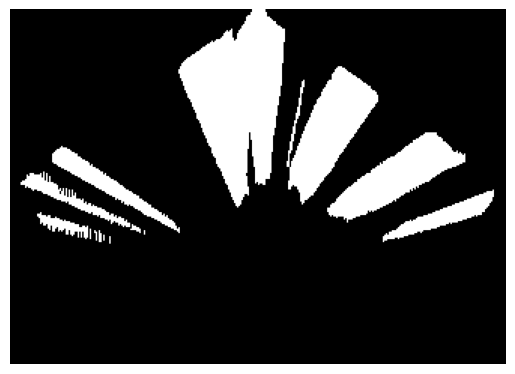

In [184]:
# single_class_bev.py
import os, cv2, numpy as np
from dataclasses import dataclass

# ---------- BEV core ----------
@dataclass
class BEVGrid:
    meters_per_pixel: float = 0.10
    forward_range_m: tuple[float, float] = (0.5, 40.0)     # (y_min, y_max)
    lateral_range_m: tuple[float, float] = (-8.0, 8.0)     # (x_min, x_max)

    @property
    def size(self) -> tuple[int, int]:
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        return np.array([[ mpp,  0.0, x_min],
                         [ 0.0, -mpp, y_max],
                         [ 0.0,  0.0, 1.0 ]], dtype=np.float64)

class BEVProjector:
    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0; self.pitch = 0.0; self.yaw = 0.0; self.height_m = 1.0
        self._H_pg = None

    def set_intrinsics(self, K: np.ndarray):
        self.K = self._validate_K(K); self._H_pg = None; return self

    def set_pose(self, height_m: float, roll: float=0.0, pitch: float=0.0, yaw: float=0.0):
        self.height_m=float(height_m); self.roll=float(roll); self.pitch=float(pitch); self.yaw=float(yaw); self._H_pg=None; return self

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3,3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        R_align = np.array([[1,0,0],[0,0,-1],[0,1,0]], dtype=np.float64)
        cz,sz = np.cos(yaw),np.sin(yaw)
        cy,sy = np.cos(pitch),np.sin(pitch)
        cx,sx = np.cos(roll),np.sin(roll)
        Rz = np.array([[cz,-sz,0],[sz,cz,0],[0,0,1]], np.float64)
        Ry = np.array([[cy,0,sy],[0,1,0],[-sy,0,cy]], np.float64)
        Rx = np.array([[1,0,0],[0,cx,-sx],[0,sx,cx]], np.float64)
        return R_align @ (Rx @ Ry @ Rz)

    def _ground_to_image_homography(self) -> np.ndarray:
        if self._H_pg is not None: return self._H_pg
        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)
        t_wc = np.array([[0.0],[0.0],[self.height_m]], dtype=np.float64)
        r1, r2 = R_wc[:,0:1], R_wc[:,1:2]
        t = R_wc @ (-t_wc)
        self._H_pg = self.K @ np.hstack([r1, r2, t])
        return self._H_pg

def _build_intrinsics(W, H, K0=None, K0_size=None, fx=1100.0, fy=None):
    if K0 is not None and K0_size is not None:
        W0,H0 = K0_size; sx,sy = W/float(W0), H/float(H0)
        return np.array([[K0[0,0]*sx, 0, K0[0,2]*sx],
                         [0, K0[1,1]*sy, K0[1,2]*sy],
                         [0, 0, 1]], dtype=np.float64)
    if fy is None: fy = fx
    cx,cy = W/2.0, H/2.0
    return np.array([[fx,0,cx],[0,fy,cy],[0,0,1]], dtype=np.float64)

# ---------- Robust single-class mask creation ----------
def load_labels_to_mask_video(path: str, class_id: int, *, background_ids=(0,), num_classes=12) -> np.ndarray:
    """
    Accepts labels either (T,H,W) of raw ids or (T,H,W,K) one-hot.
    Returns (T,H,W) binary in {0,1} for the chosen class_id (1..K).
    Ignores background and stray labels safely.
    """
    assert os.path.exists(path), f"not found: {path}"
    arr = np.load(path)
    if arr.ndim == 3:
        # raw ids
        T,H,W = arr.shape
        mask = (arr == class_id).astype(np.uint8)
        for b in background_ids:
            # just ensures background never lights up
            mask[arr == b] = 0
        return mask
    elif arr.ndim == 4:
        # one-hot
        T,H,W,K = arr.shape
        if not (1 <= class_id <= K): raise ValueError(f"class_id {class_id} not in 1..{K}")
        return (arr[..., class_id-1] > 0).astype(np.uint8)
    else:
        raise ValueError(f"Unexpected npy shape: {arr.shape}")

# ---------- Project (T,H,W) binary -> (T,Hb,Wb) binary ----------
def bev_project_binary_video(
    mask_video: np.ndarray,   # (T,H,W) in {0,1}
    *,
    height_m=1.4, pitch_deg_down=6.0, roll_deg=0.0, yaw_deg=0.0,
    fx=1100.0, fy=None, K0=None, K0_size=None,
    meters_per_pixel=0.10, forward_range=(0.5,40.0), lateral_range=(-8.0,8.0),
    binarize_threshold=127
):
    assert mask_video.ndim == 3
    T,H,W = mask_video.shape
    Kcam = _build_intrinsics(W,H,K0,K0_size,fx,fy)
    roll = np.deg2rad(roll_deg); pitch = -np.deg2rad(pitch_deg_down); yaw = np.deg2rad(yaw_deg)

    proj = BEVProjector().set_intrinsics(Kcam).set_pose(height_m, roll, pitch, yaw)
    grid = BEVGrid(meters_per_pixel=meters_per_pixel, forward_range_m=forward_range, lateral_range_m=lateral_range)

    H_pg = proj._ground_to_image_homography()
    S = grid.scaling_matrix()
    M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
    Wb,Hb = grid.size
    bev = np.zeros((T, Hb, Wb), dtype=np.uint8)

    for t in range(T):
        src = (mask_video[t].astype(np.uint8) * 255)
        dst = cv2.warpPerspective(src, M, (Wb,Hb), flags=cv2.INTER_NEAREST, borderValue=0)
        bev[t] = (dst > binarize_threshold).astype(np.uint8)
    return bev, proj, grid

# ---------- Fixed-canvas rotate+shift combine for two cams ----------
def rotate_shift_canvas_size(H, W, angle_deg, hor_shift_px):
    center = (W/2.0, H/2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0,2] -= hor_shift_px; M2[0,2] += hor_shift_px

    def corners(M):
        cs = np.array([[0,0],[W,0],[W,H],[0,H]], np.float32)
        ones = np.ones((4,1), np.float32)
        return (M @ np.hstack([cs,ones]).T).T

    allc = np.vstack([corners(M1), corners(M2)])
    min_xy = np.floor(allc.min(axis=0)).astype(int)
    max_xy = np.ceil(allc.max(axis=0)).astype(int)
    out_W = int(max_xy[0]-min_xy[0]); out_H = int(max_xy[1]-min_xy[1])
    return out_H, out_W, -int(min_xy[0]), -int(min_xy[1])

def combine_two_bev_single(bev_left: np.ndarray, bev_right: np.ndarray,
                           *, angle_deg: float, hor_shift_px: int) -> np.ndarray:
    """
    bev_left/right: (T,Hb,Wb) in {0,1}. Returns (T, Ho, Wo) in {0,1}.
    """
    assert bev_left.shape == bev_right.shape
    T,H,W = bev_left.shape
    out_H,out_W,sx,sy = rotate_shift_canvas_size(H,W,angle_deg,hor_shift_px)
    out = np.zeros((T,out_H,out_W), dtype=np.uint8)

    center = (W/2.0, H/2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0,2] += sx - hor_shift_px; M1[1,2] += sy
    M2[0,2] += sx + hor_shift_px; M2[1,2] += sy

    for t in range(T):
        L = (bev_left[t]*255).astype(np.uint8)
        R = (bev_right[t]*255).astype(np.uint8)
        w1 = cv2.warpAffine(L, M1, (out_W,out_H), flags=cv2.INTER_NEAREST, borderValue=0)
        w2 = cv2.warpAffine(R, M2, (out_W,out_H), flags=cv2.INTER_NEAREST, borderValue=0)
        out[t] = (cv2.add(w1,w2) > 127).astype(np.uint8)
    return out

def dilate_erode_blur_slice(
    image: np.ndarray, 
    kernel_size: int = 5,     
    blur_ksize: int = 7,
    blur_sigma: float = 1.0
    ) -> np.ndarray:
    """
    Performs dilation followed by erosion (closing) on the slice tensor_hwn[:, :, 50].

    Parameters:
        tensor_hwn (np.ndarray): Input tensor of shape (H, W, N)
        kernel_size (int): Size of the square kernel (default: 5)

    Returns:
        np.ndarray: Closed (dilated + eroded) version of slice [:, :, 50]
    """

    img = image.astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    
    closed = cv2.erode(img, kernel)
    dilated = cv2.dilate(closed, kernel)

    
    blurred = cv2.GaussianBlur(dilated, (blur_ksize, blur_ksize), blur_sigma)

    

    return blurred



# ---------- Example usage ----------
if __name__ == "__main__":
    # choose your label id (1..12), e.g. road=1
    CLASS_ID = 13

    cam1 = "/workspace/test_results/cam1_1754490274.npy"
    cam2 = "/workspace/test_results/cam2_1754490274.npy"

    # Build single-class masks then BEV per cam
    mask1 = load_labels_to_mask_video(cam1, CLASS_ID, background_ids=())
    mask2 = load_labels_to_mask_video(cam2, CLASS_ID, background_ids=())

    bev1, proj1, grid1 = bev_project_binary_video(
        mask1, pitch_deg_down=0.0, height_m=1.0, fx=300, fy=int(530/380*200),
        meters_per_pixel=0.20, forward_range=(0.5,30.0), lateral_range=(-20.0,20.0)
    )
    bev2, proj2, grid2 = bev_project_binary_video(
        mask2, pitch_deg_down=0.0, height_m=1.0, fx=380.0, fy=530,
        meters_per_pixel=0.20, forward_range=(0.5,30.0), lateral_range=(-20.0,20.0)
    )

    # Combine cams in a fixed canvas
    combined = combine_two_bev_single(
        bev_left=bev2, bev_right=bev1,  # follow your previous convention
        angle_deg=-35, hor_shift_px=-40
    )
    denoised = dilate_erode_blur_slice(combined, kernel_size=3, blur_sigma=5, blur_ksize=11)


    # quick sanity check image
    import matplotlib.pyplot as plt
    plt.imshow(denoised[0], cmap="gray"); plt.axis("off"); plt.show()


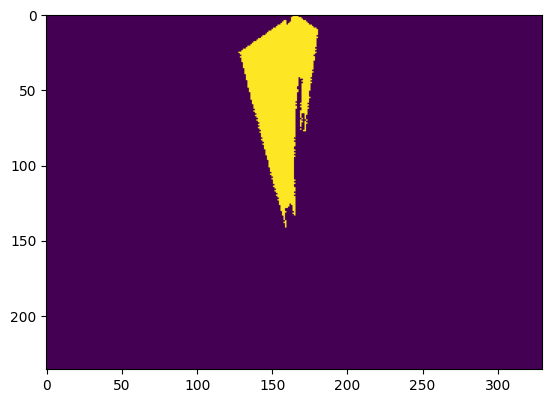

In [75]:
n = 240
plt.imshow(combined[n])

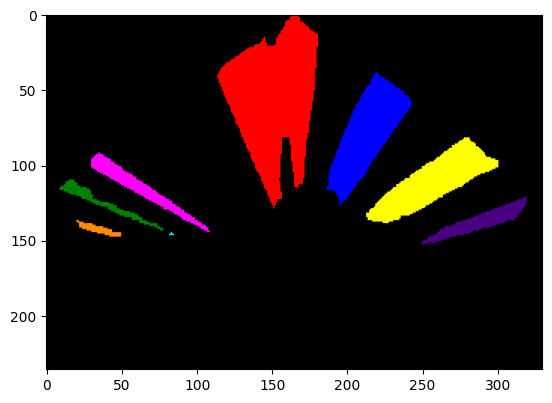

In [185]:
import numpy as np
from scipy.ndimage import label
from skimage.color import label2rgb
from skimage.morphology import erosion, square

import numpy as np
from scipy.ndimage import label
from skimage.color import label2rgb
from skimage.morphology import erosion
from skimage.morphology import binary_erosion  # boolean morphology


def color_segments_skimage_batch(arr, connectivity=8, horizontal_erosion_size=1, batch_axis=0):
    """
    arr: binary array with a batch axis (N,H,W) or (H,W,N)
    connectivity: 4 or 8
    horizontal_erosion_size: half-width of horizontal kernel (1 -> width=3)
    batch_axis: which axis is the batch (0 for (N,H,W), 2 for (H,W,N))
    returns: labeled_stack (N,H,W), rgb_stack (N,H,W,3)
    """
    # Move batch axis to axis 0 -> (N, H, W)
    arr = np.moveaxis(arr, batch_axis, 0)
    N, H, W = arr.shape

    # Horizontal structuring element: (1, kernel_width)
    selem = None
    if horizontal_erosion_size > 0:
        kernel_width = 2 * horizontal_erosion_size + 1
        selem = np.ones((1, kernel_width), dtype=bool)

    # Connectivity structure for labeling
    structure = np.ones((3,3), int) if connectivity == 8 else np.array([[0,1,0],[1,1,1],[0,1,0]], int)

    labeled_list = []
    rgb_list = []
    for i in range(N):
        binary = arr[i].astype(bool)

        if selem is not None:
            # Erode horizontally only (no vertical erosion)
            binary = binary_erosion(binary, footprint=selem)

        labeled, _ = label(binary, structure=structure)
        rgb = (255 * label2rgb(labeled, bg_label=0, bg_color=(0,0,0))).astype(np.uint8)

        labeled_list.append(labeled)
        rgb_list.append(rgb)

    labeled_stack = np.stack(labeled_list)       # (N,H,W)
    rgb_stack = np.stack(rgb_list)               # (N,H,W,3)

    # Move batch axis back to original place for both outputs
    labeled_stack = np.moveaxis(labeled_stack, 0, batch_axis)
    rgb_stack     = np.moveaxis(rgb_stack,     0, batch_axis)

    return labeled_stack, rgb_stack

n = 150

labeled, rgb = color_segments_skimage_batch(denoised, connectivity=8, horizontal_erosion_size=2, batch_axis=0)
plt.imshow(rgb[0])

In [133]:
import numpy as np

def pick_bottom_middle_points(labeled, m, y_min=0, center_x=None):
    """
    labeled: (H,W) int array (0 = background, 1..K = components)
    m: keep components with size > m
    y_min: only return points with row >= y_min (i.e., 'below' that screen height)
    center_x: x-coordinate of 'screen middle' (defaults to W/2)

    Returns:
      coords: array of shape (P, 3) with [y, x, label] for kept components.
              P can be 0 if nothing passes filters.
    """
    labeled = np.asarray(labeled)
    assert labeled.ndim == 2, "Expected a single labeled image of shape (H, W)."
    H, W = labeled.shape
    if center_x is None:
        center_x = (W - 1) / 2.0
    bottom_y = H - 1

    # component sizes (ignore label 0)
    counts = np.bincount(labeled.ravel())
    if counts.size <= 1:
        return np.empty((0, 3), dtype=int)
    valid_labels = np.flatnonzero(counts > m)
    valid_labels = valid_labels[valid_labels != 0]
    if valid_labels.size == 0:
        return np.empty((0, 3), dtype=int)

    ys, xs = np.nonzero(labeled > 0)
    labs = labeled[ys, xs]

    # mask to only candidates from valid labels
    mask = np.isin(labs, valid_labels)
    ys, xs, labs = ys[mask], xs[mask], labs[mask]

    # distances to bottom-middle (Euclidean, squared is fine)
    d2 = (ys - bottom_y)**2 + (xs - center_x)**2

    # for each label, pick index of min distance
    # we’ll map labels -> best index using argmin per label
    best_idx = {}
    # iterate over all pixels once
    for i, L in enumerate(labs):
        if (L not in best_idx) or (d2[i] < d2[best_idx[L]]):
            best_idx[L] = i

    # collect chosen points
    chosen = []
    for L, i in best_idx.items():
        y, x = int(ys[i]), int(xs[i])
        if y >= y_min:  # only keep points below the cutoff line
            chosen.append((y, x, int(L)))

    if not chosen:
        return np.empty((0, 3), dtype=int)

    # sort by y descending (closest to bottom first), then by |x-center|
    chosen.sort(key=lambda t: (-(t[0]), abs(t[1] - center_x)))
    return np.asarray(chosen, dtype=int)


def pick_bottom_middle_points_batch(labeled_stack, m, y_min=0, center_x=None, batch_axis=0):
    """
    labeled_stack: (N,H,W) or (H,W,N) labeled maps
    Returns: list of length N, each item is an array (Pi, 3) with [y,x,label]
    """
    arr = np.moveaxis(labeled_stack, batch_axis, 0)  # -> (N,H,W)
    out = []
    for lbl in arr:
        out.append(pick_bottom_middle_points(lbl, m=m, y_min=y_min, center_x=center_x))
    return out


# Single image:
# pts -> array [[y, x, label], ...]

# Batch (N,H,W):
pts_list = pick_bottom_middle_points_batch(labeled, m=0, y_min=0)
# pts_list[i] -> points for frame i



/tmp/ipykernel_148/34126559.py:188: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")


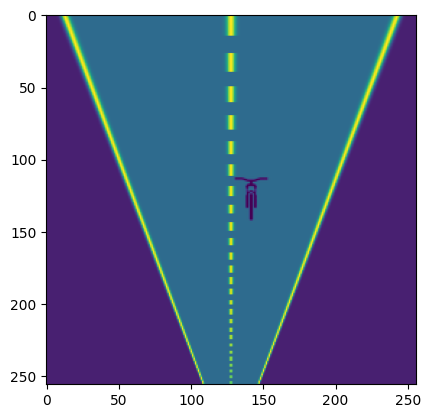

In [146]:
import numpy as np
from PIL import Image

# ---------------- Road generator (unchanged) ----------------
def make_road_image(h=256, w=256,
                    road_width_bottom=0.9, road_width_top=0.15,
                    edge_thickness=2, dash_period=28, dash_duty=0.55,
                    bg_val=20, road_val=80, edge_val=230, dash_val=230):
    y = np.arange(h)[:, None]
    x = np.arange(w)[None, :]
    t = y / (h - 1.0)
    tb = 1.0 - t

    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w = half_w_top + (half_w_bot - half_w_top) * tb
    cx = (w - 1) / 2.0
    dist = np.abs(x - cx)

    img = np.full((h, w), bg_val, dtype=np.float32)

    edge_soft = 0.6 + (1.6 - 0.6) * tb
    road_mask = 1.0 - np.clip((dist - half_w) / np.maximum(edge_soft, 1e-6), 0, 1)
    img = img * (1 - road_mask) + road_val * road_mask

    thick = 0.5 + (edge_thickness - 0.5) * tb
    edge_dist = np.abs(dist - half_w)
    edge_mask = np.exp(-(edge_dist**2) / (2*(np.maximum(thick,1e-6)**2)))
    img = img * (1 - edge_mask) + edge_val * edge_mask

    center_thick = 0.5 + (2.2 - 0.5) * tb
    period = 10.0 + (dash_period - 10.0) * tb
    dash_len = dash_duty * period
    phase = (y / np.maximum(period, 1e-6)) % 1.0
    is_dash = (phase <= (dash_len / np.maximum(period,1e-6))).astype(np.float32)
    centerline_profile = np.exp(-(dist**2) / (2*(np.maximum(center_thick,1e-6)**2)))
    centerline_mask = centerline_profile * is_dash * road_mask
    img = img * (1 - centerline_mask) + dash_val * centerline_mask

    return np.clip(img, 0, 255).astype(np.uint8)

# ---- Helper: compute road half-width per row (so we can scale sprite by lane width) ----
def compute_half_widths(h, w, road_width_bottom, road_width_top):
    y = np.arange(h)[:, None]
    t = y / (h - 1.0)
    tb = 1.0 - t
    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w = (half_w_top + (half_w_bot - half_w_top) * tb).astype(np.float32)  # (H,1)
    return half_w  # each row’s half width from center to edge

# ---------------- Sprites: load, resize, and alpha-compose ----------------
def load_rgba(path):
    im = Image.open(path).convert("RGBA")
    arr = np.asarray(im).astype(np.float32) / 255.0
    return arr

def resize_rgba(arr, new_h=None, new_w=None):
    im = Image.fromarray((arr * 255).astype(np.uint8), mode="RGBA")
    if new_h and not new_w:
        w = int(round(im.width * (new_h / im.height)))
        size = (w, new_h)
    elif new_w and not new_h:
        h = int(round(im.height * (new_w / im.width)))
        size = (new_w, h)
    else:
        size = (new_w, new_h)
    im = im.resize(size, Image.LANCZOS)
    return np.asarray(im).astype(np.float32) / 255.0

def alpha_over_gray(base_gray_u8, sprite_rgba_f32, top, left):
    H, W = base_gray_u8.shape
    sh, sw = sprite_rgba_f32.shape[:2]

    y0, x0 = max(0, top), max(0, left)
    y1, x1 = min(H, top + sh), min(W, left + sw)
    if y0 >= y1 or x0 >= x1:
        return base_gray_u8  # fully out of frame

    sy0, sx0 = y0 - top, x0 - left
    sy1, sx1 = sy0 + (y1 - y0), sx0 + (x1 - x0)

    base = base_gray_u8.astype(np.float32)
    spr = sprite_rgba_f32[sy0:sy1, sx0:sx1, :]  # (h,w,4)

    r, g, b, a = spr[..., 0], spr[..., 1], spr[..., 2], spr[..., 3]
    lum = 0.2126 * r + 0.7152 * g + 0.0722 * b  # grayscale sprite in [0,1]
    region = base[y0:y1, x0:x1]
    out_region = (lum * 255.0) * a + region * (1.0 - a)
    base[y0:y1, x0:x1] = out_region
    return np.clip(base, 0, 255).astype(np.uint8)

# ---------------- New: place icons at arbitrary filtered points ----------------
def place_icons_on_image(
    img_gray_u8,
    points,
    bike_path="bajs_ikonica.png",
    *,
    fixed_width_px=None,
    scale_by_lane=None,
    lane_scale=0.55,
    road_width_bottom=0.4,
    road_width_top=0.3,
):
    """
    Draw the bike icon at given points.

    Args:
      img_gray_u8: (H,W) uint8 grayscale road image.
      points: iterable of (y, x) integer coords. (icon bottom aligns to y, centered at x)
      bike_path: RGBA icon path.
      fixed_width_px: if set, use this exact icon width in px for all points.
      scale_by_lane: if True, scale icon width by lane width at each point's row using
                     road_width_bottom/top params (matches your generator).
      lane_scale: fraction of (full road width) to use as icon width, e.g. 0.55.
      road_width_bottom, road_width_top: used to compute lane width per row if scale_by_lane=True.

    Returns:
      New (H,W) uint8 image with icons rendered.
    """
    img = img_gray_u8.copy()
    H, W = img.shape
    sprite_orig = load_rgba(bike_path)

    # Precompute per-row road width if requested
    half_w = None
    if scale_by_lane:
        half_w = compute_half_widths(H, W, road_width_bottom, road_width_top)  # (H,1)

    for (y, x) in points:
        # Choose target sprite width
        if fixed_width_px is not None:
            target_w = int(max(8, round(fixed_width_px)))
        elif scale_by_lane:
            # Full road width at this row = 2*half_w[y]
            hw = float(half_w[min(max(int(y), 0), H-1), 0])
            target_w = int(max(8, round((2.0 * hw) * lane_scale)))
        else:
            # Fallback: reasonable default
            target_w = 48

        sprite = resize_rgba(sprite_orig, new_w=target_w)
        sh, sw = sprite.shape[:2]

        # Place so bottom sits at y and center at x
        top = int(round(y - sh))
        left = int(round(x - sw / 2.0))
        img = alpha_over_gray(img, sprite, top=top, left=left)

    return img

# ---------------- Convenience wrapper: generate road + place icons ----------------
def make_road_with_icons(
    points,
    h=256, w=256,
    bike_path="bajs_ikonica.png",
    road_width_bottom=0.4, road_width_top=0.3,
    use_lane_scaling=True, lane_scale=0.55, fixed_width_px=None
):
    """
    Creates a road image and renders the bike icon at each (y,x) in `points`.
    """
    img = np.flipud(make_road_image(h, w, road_width_bottom=road_width_bottom, road_width_top=road_width_top))
    img = place_icons_on_image(
        img, points, bike_path=bike_path,
        fixed_width_px=fixed_width_px,
        scale_by_lane=use_lane_scaling,
        lane_scale=lane_scale,
        road_width_bottom=road_width_bottom,
        road_width_top=road_width_top,
    )
    return img

# ---------------- Example ----------------


import numpy as np
from PIL import Image

# ---------- Sprite helpers ----------
def load_rgba(path):
    """Load an image as float32 RGBA in [0,1], shape (H,W,4)."""
    im = Image.open(path).convert("RGBA")
    return np.asarray(im).astype(np.float32) / 255.0

def resize_rgba(arr_rgba, new_w=None, new_h=None):
    """Resize RGBA to given width/height (one or both)."""
    im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")
    if new_h and not new_w:
        new_w = int(round(im.width * (new_h / im.height)))
    elif new_w and not new_h:
        new_h = int(round(im.height * (new_w / im.width)))
    elif not (new_w and new_h):
        raise ValueError("Provide new_w or new_h (or both).")
    im = im.resize((new_w, new_h), Image.LANCZOS)
    return np.asarray(im).astype(np.float32) / 255.0

def alpha_over(base, sprite_rgba, top, left):
    """
    Alpha composite sprite_rgba (H,W,4) over base.
    base: uint8 (H,W) or (H,W,3)
    Returns new uint8 image.
    """
    base = np.asarray(base)
    H, W = base.shape[:2]
    sh, sw = sprite_rgba.shape[:2]

    # Clipping
    y0, x0 = max(0, top), max(0, left)
    y1, x1 = min(H, top + sh), min(W, left + sw)
    if y0 >= y1 or x0 >= x1:
        return base  # fully outside

    sy0, sx0 = y0 - top, x0 - left
    sy1, sx1 = sy0 + (y1 - y0), sx0 + (x1 - x0)

    spr = sprite_rgba[sy0:sy1, sx0:sx1, :]  # (h,w,4)
    a = spr[..., 3:4]                        # (h,w,1) alpha in [0,1]
    rgb = spr[..., :3]                       # (h,w,3) in [0,1]

    if base.ndim == 2:
        # Convert sprite RGB to luminance for grayscale base
        lum = (0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2])[..., None]  # (h,w,1)
        region = base[y0:y1, x0:x1].astype(np.float32)[..., None] / 255.0                       # (h,w,1)
        out = lum * a + region * (1.0 - a)
        base_out = base.copy().astype(np.float32)
        base_out[y0:y1, x0:x1] = (out[..., 0] * 255.0)
        return np.clip(base_out, 0, 255).astype(np.uint8)
    else:
        # Color compositing
        region = base[y0:y1, x0:x1, :].astype(np.float32) / 255.0
        out = rgb * a + region * (1.0 - a)
        base_out = base.copy().astype(np.float32)
        base_out[y0:y1, x0:x1, :] = (out * 255.0)
        return np.clip(base_out, 0, 255).astype(np.uint8)

# ---------- Draw icons using points from pick_bottom_middle_points ----------
def draw_icons_on_image(img, pts, icon_path, width_px=48, height_px=None):
    """
    img: uint8 (H,W) or (H,W,3)
    pts: array-like of (y, x) or (y, x, label)  -- label is ignored here
    icon_path: path to RGBA icon (e.g., "bajs_ikonica.png")
    width_px: target icon width
    height_px: optional target height (keeps aspect if None)

    Returns: new image with icons composited.
    """
    if isinstance(pts, np.ndarray) and pts.shape[-1] == 3:
        pts = pts[:, :2]  # drop label if present

    sprite0 = load_rgba(icon_path)
    sprite = resize_rgba(sprite0, new_w=width_px) if height_px is None else resize_rgba(sprite0, new_w=width_px, new_h=height_px)

    out = img.copy()
    for (y, x) in pts:
        sh, sw = sprite.shape[:2]
        top  = int(round(y - sh))           # bottom aligns to y
        left = int(round(x - sw / 2.0))     # center aligns to x
        out = alpha_over(out, sprite, top, left)
    return out

def draw_icons_on_frames(frames, pts_list, icon_path, width_px=48, height_px=None):
    """
    frames: (N,H,W) or (N,H,W,3) uint8
    pts_list: list of length N, each entry an array of (y,x) or (y,x,label)
    Returns: frames_out with icons drawn on each frame.
    """
    frames = np.asarray(frames)
    assert frames.ndim in (3,4), "frames must be (N,H,W) or (N,H,W,3)"
    N = frames.shape[0]
    assert len(pts_list) == N, "pts_list length must match frames count"

    sprite0 = load_rgba(icon_path)
    sprite = resize_rgba(sprite0, new_w=width_px) if height_px is None else resize_rgba(sprite0, new_w=width_px, new_h=height_px)

    outs = []
    for i in range(N):
        img = frames[i]
        pts = pts_list[i]
        if isinstance(pts, np.ndarray) and pts.ndim > 1 and pts.shape[-1] >= 2:
            pts_iter = pts[:, :2]
        else:
            pts_iter = pts
        out = img.copy()
        for (y, x) in pts_iter:
            sh, sw = sprite.shape[:2]
            top  = int(round(y - sh))
            left = int(round(x - sw / 2.0))
            out = alpha_over(out, sprite, top, left)
        outs.append(out)
    return np.stack(outs, axis=0)


# Get points for one labeled image
i = 0  # pick a specific frame
labeled_single = labeled[i]  # now it's (H, W)

pts = pick_bottom_middle_points(labeled_single, m=50, y_min=int(0.6*labeled_single.shape[0]))
# Draw icons on your base image (grayscale or RGB)
base_img = make_road_image(h=256, w=256)  # or whatever size you used for labeling


img_with_icons = draw_icons_on_image(base_img, pts, icon_path="bajs_ikonica.png", width_px=48)


plt.imshow(img_with_icons)


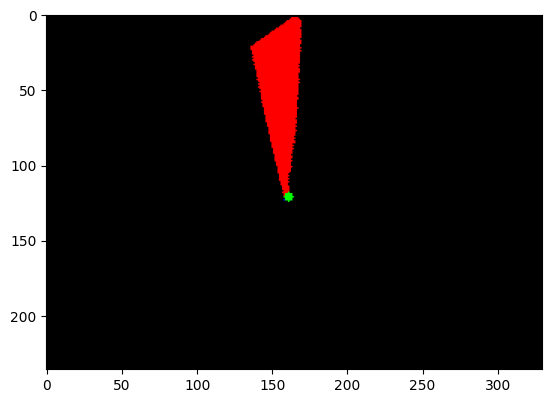

In [174]:
import numpy as np
import cv2  # OpenCV is very convenient for drawing

import numpy as np
from skimage.color import label2rgb
import cv2

def draw_dots_on_labeled_color(labeled, pts, radius=4, dot_color=(255, 0, 0)):
    """
    labeled: (H,W) int labels (0=bg)
    pts: array-like of (y,x) or (y,x,label)
    Returns: (H,W,3) uint8 color image with dots over a colorized label map.
    """
    # Colorize labels (float RGB in [0,1]); bg stays black
    color = label2rgb(labeled, bg_label=0, bg_color=(0,0,0))
    img_rgb = (color * 255).astype(np.uint8)

    pts = np.asarray(pts)
    if pts.ndim > 1 and pts.shape[-1] >= 2:
        pts = pts[:, :2]  # ignore label if present

    for y, x in pts:
        cv2.circle(img_rgb, (int(x), int(y)), radius, dot_color, thickness=-1)
    return img_rgb



# Given:
# labeled_single: (H,W) labeled image
# pts: array like [[y, x, label], ...]
i = 250
labeled_single = labeled[i] 
pts = pick_bottom_middle_points(labeled_single, m=80, y_min=int(0.4*labeled_single.shape[0]))

dot_img = draw_dots_on_labeled_color(labeled_single, pts, radius=3, dot_color=(0,255,0))

import matplotlib.pyplot as plt
plt.imshow(dot_img)
plt.axis('on')
plt.show()


In [186]:
dot_images = []

for i in range(labeled.shape[0]):
    labeled_single = labeled[i]
    
    pts = pick_bottom_middle_points(
        labeled_single,
        m=150,
        y_min=int(0.4 * labeled_single.shape[0])
    )
    
    dot_img = draw_dots_on_labeled_color(
        np.asarray(labeled_single),
        pts,
        radius=3,
        dot_color=(0, 255, 0)
    )
    
    dot_images.append(dot_img)

# Convert to numpy tensor (N, H, W, 3)
dot_tensor = np.stack(dot_images, axis=0)


In [190]:
import numpy as np
from skimage.color import label2rgb
from PIL import Image

# --- simple RGBA helpers ---
def load_rgba(path):
    im = Image.open(path).convert("RGBA")
    return np.asarray(im).astype(np.float32) / 255.0

def resize_rgba(arr_rgba, new_w=None, new_h=None):
    im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")
    if new_h and not new_w:
        new_w = int(round(im.width * (new_h / im.height)))
    elif new_w and not new_h:
        new_h = int(round(im.height * (new_w / im.width)))
    elif not (new_w and new_h):
        raise ValueError("Provide new_w or new_h (or both).")
    im = im.resize((new_w, new_h), Image.LANCZOS)
    return np.asarray(im).astype(np.float32) / 255.0

def alpha_over(base_u8, sprite_rgba, top, left):
    base = np.asarray(base_u8)
    H, W = base.shape[:2]
    sh, sw = sprite_rgba.shape[:2]

    y0, x0 = max(0, top), max(0, left)
    y1, x1 = min(H, top + sh), min(W, left + sw)
    if y0 >= y1 or x0 >= x1:
        return base

    sy0, sx0 = y0 - top, x0 - left
    sy1, sx1 = sy0 + (y1 - y0), sx0 + (x1 - x0)

    spr = sprite_rgba[sy0:sy1, sx0:sx1, :]         # (h,w,4) float32 [0,1]
    a   = spr[..., 3:4]
    rgb = spr[..., :3]

    # ensure base is RGB
    if base.ndim == 2:
        base = np.stack([base]*3, axis=-1)
    region = base[y0:y1, x0:x1, :].astype(np.float32) / 255.0
    out = rgb * a + region * (1.0 - a)

    base_out = base.copy().astype(np.float32)
    base_out[y0:y1, x0:x1, :] = out * 255.0
    return np.clip(base_out, 0, 255).astype(np.uint8)

def draw_icons_on_image(img_rgb_u8, pts, icon_path, width_px=48, height_px=None):
    """Draw icon at each (y,x) in pts on an RGB/gray image."""
    sprite0 = load_rgba(icon_path)
    sprite  = resize_rgba(sprite0, new_w=width_px) if height_px is None else resize_rgba(sprite0, new_w=width_px, new_h=height_px)

    # Accept pts as (y,x) or (y,x,label)
    pts = np.asarray(pts)
    if pts.ndim > 1 and pts.shape[-1] >= 2:
        pts = pts[:, :2]

    out = img_rgb_u8.copy()
    for (y, x) in pts:
        sh, sw = sprite.shape[:2]
        top  = int(round(y - sh))           # bottom aligns to y
        left = int(round(x - sw / 2.0))     # center aligns to x
        out = alpha_over(out, sprite, top, left)
    return out



ICON_PATH = "car_icon.png"   # set to your icon path
dot_images = []

for i in range(labeled.shape[0]):
    labeled_single = labeled[i]

    pts = pick_bottom_middle_points(
        labeled_single,
        m=150,
        y_min=int(0.4 * labeled_single.shape[0])
    )

    # Colorize the labeled map as background (like your dot viz)
    base_rgb = (label2rgb(labeled_single, bg_label=0, bg_color=(0,0,0)) * 255).astype(np.uint8)

    # Draw icons instead of dots
    base_rgb[:] = 0
    icon_img = draw_icons_on_image(
        base_rgb,
        pts,
        icon_path=ICON_PATH,
        width_px=48   # tweak as you like
    )

    dot_images.append(icon_img)

# Tensor (N, H, W, 3)
icon_tensor = np.stack(dot_images, axis=0)


/tmp/ipykernel_148/3146496662.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")


In [191]:
t2v(np.transpose(icon_tensor, (1, 2, 3, 0)), "pracenje_kola_ikonicama.mp4", fps=15)

In [177]:
dot_tensor.shape

(300, 236, 330, 3)

In [156]:
labeled_single.shape

(236, 330)

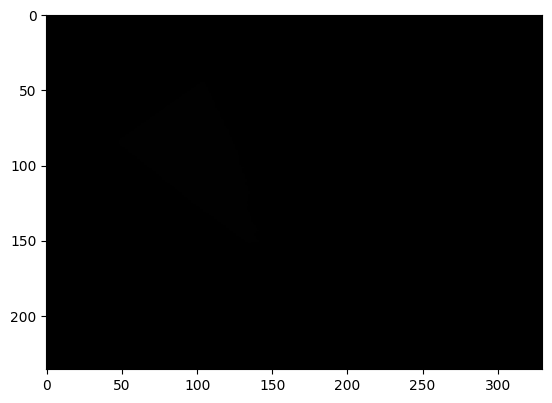

In [155]:
plt.imshow(dot_img)

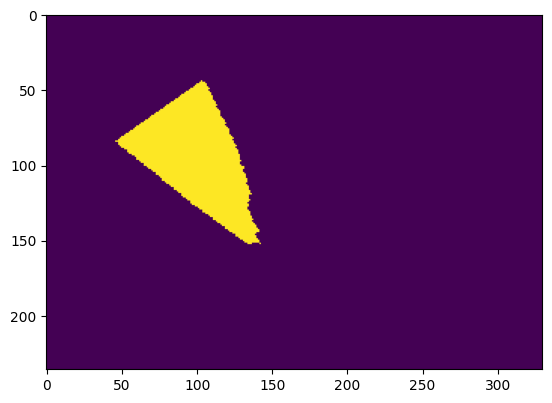

In [151]:
plt.imshow(labeled_single)

In [149]:
pts

array([[152, 142,   1]])

In [141]:
pts_list[]

array([[152, 142,   1]])

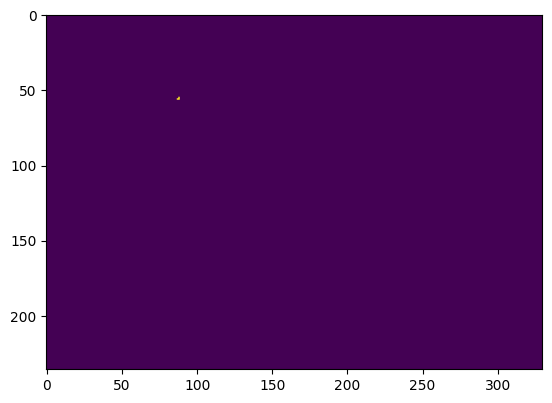

In [127]:
plt.imshow(labeled[160])

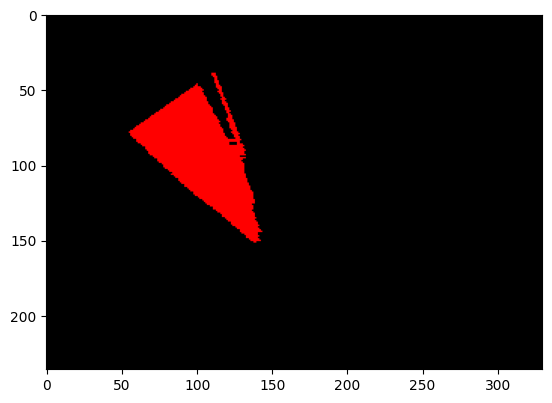

In [115]:
plt.imshow(rgb[2])

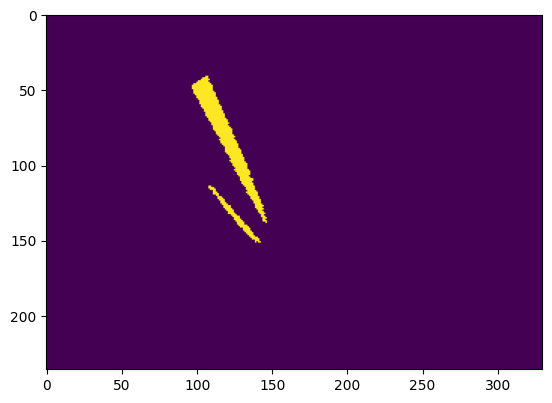

In [108]:
plt.imshow(combined[n])

In [40]:
import numpy as np
from scipy.ndimage import rotate

def rotate_images(images, angle_deg):
    # images: (N, H, W)
    # Returns: rotated_images: (N, H, W)
    rotated_images = np.array([
        rotate(img, angle=angle_deg, reshape=False, mode='nearest')
        for img in images
    ])
    return rotated_images

# Example usage
rotated = rotate_images(combined, 25)  # n is the angle in degrees


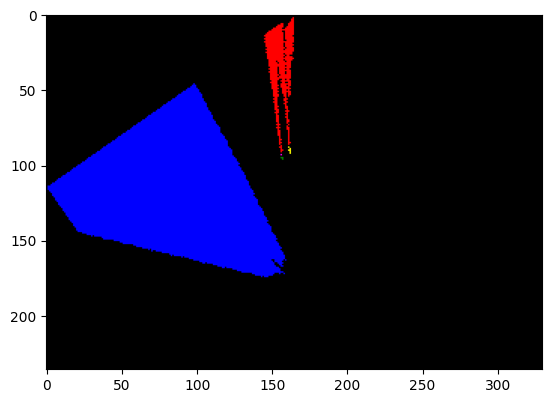

In [72]:
plt.imshow(rgb)

In [56]:
mask1.shape

(300, 480, 640)

In [119]:
import numpy as np

def to_hw3n(a):
    """
    Convert array to (H, W, 3, N) uint8 for t2v().
    Accepts: (N,H,W,3), (H,W,N,3), (N,3,H,W), (H,W,3,N), (H,W,3), (H,W)
    """
    a = np.asarray(a)

    if a.ndim == 2:                     # (H, W) -> (H,W,3,1)
        a = np.stack([a]*3, axis=2)[..., None]
    elif a.ndim == 3:
        if a.shape[2] == 3:             # (H, W, 3) -> (H,W,3,1)
            a = a[..., None]
        else:
            raise ValueError(f"3D array must be (H,W,3), got {a.shape}")
    elif a.ndim == 4:
        H,W,_,_ = (None,)*4
        # Already (H,W,3,N)
        if a.shape[2] == 3 and a.shape[3] != 3 and a.shape[0] != 3 and a.shape[1] != 3:
            pass
        # (N,H,W,3) -> (H,W,3,N)
        elif a.shape[-1] == 3 and a.shape[0] != 3:
            a = np.transpose(a, (1, 2, 3, 0))
        # (H,W,N,3) -> (H,W,3,N)
        elif a.shape[-1] == 3 and a.shape[2] != 3:
            a = np.transpose(a, (0, 1, 3, 2))
        # (N,3,H,W) -> (H,W,3,N)
        elif a.shape[1] == 3:
            a = np.transpose(a, (2, 3, 1, 0))
        # (H,W,3,N) stays
        elif a.shape[2] == 3:
            pass
        else:
            raise ValueError(f"Unrecognized 4D layout {a.shape}, need a 3-channel axis.")
    else:
        raise ValueError(f"Unsupported ndim {a.ndim}, expected 2–4")

    # Ensure uint8
    if a.dtype != np.uint8:
        a = np.clip(a, 0, 255)
        if a.max() <= 1.0:
            a = a * 255.0
        a = a.astype(np.uint8)

    return np.ascontiguousarray(a)


# Example:
# If rgb is (N,H,W,3) already: just do
# t2v(to_thwc(rgb), "/workspace/CV/found_cars.mp4", fps=15)

# If yours was (H,W,N,3), use the same helper:
# t2v(to_thwc(rgb), "/workspace/CV/found_cars.mp4", fps=15)


t2v(to_hw3n(rgb), "/workspace/CV/found_cars.mp4", fps=15)


In [26]:
combined.shape

(300, 236, 330)

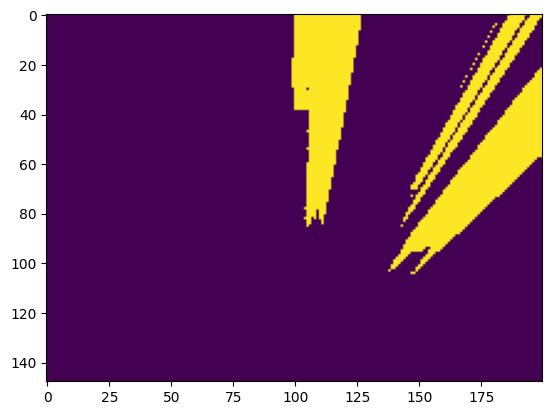

In [3]:
plt.imshow(bev1[158])

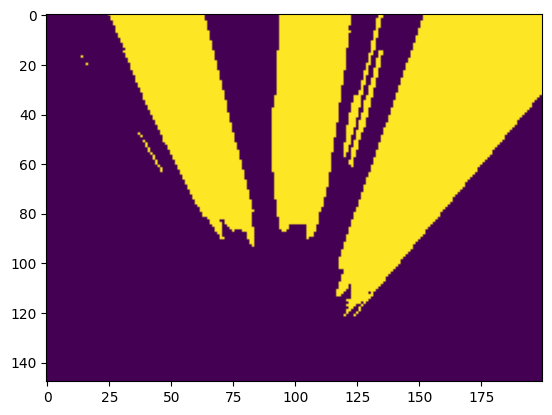

In [4]:
plt.imshow(bev2[158])

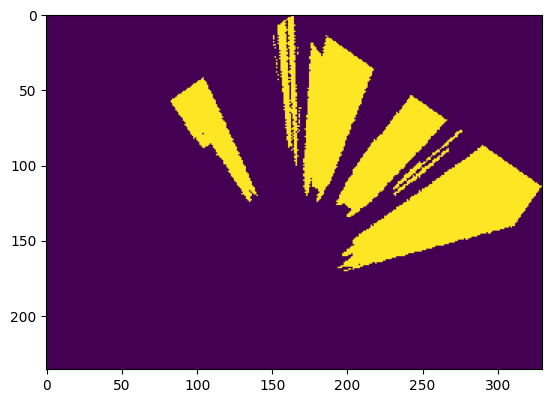

In [20]:
n = 158
plt.imshow(combined[n])

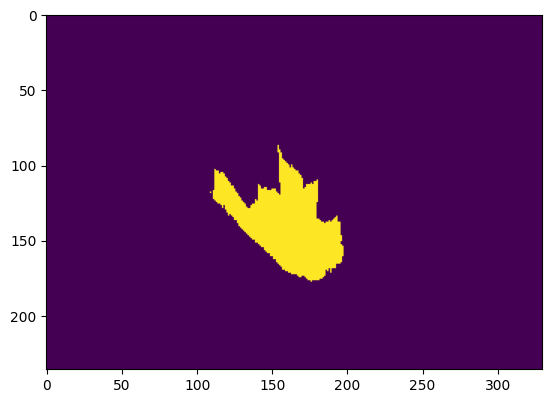

In [19]:
plt.imshow(denoised_road[n])

In [13]:
image2 = np.load("/workspace/test_results/cam2_1754490274.npy")

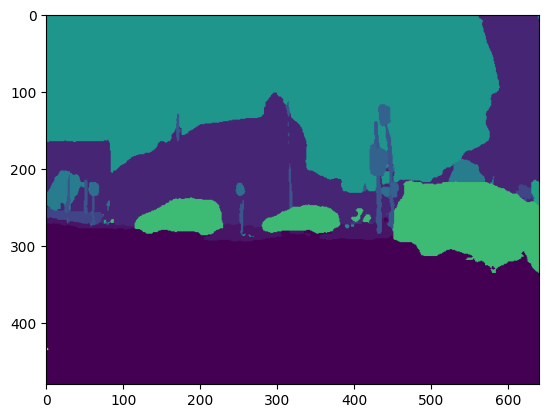

In [21]:
plt.imshow(image2[n])

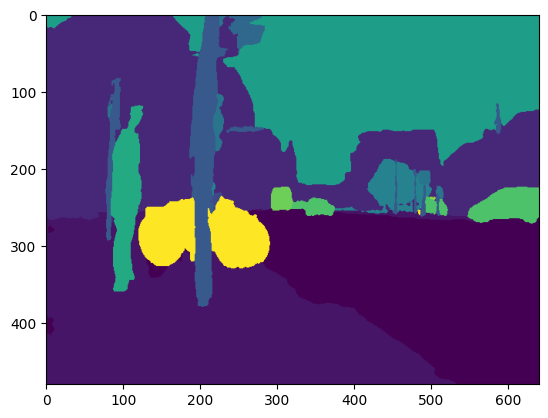

In [22]:
plt.imshow(image1[n])

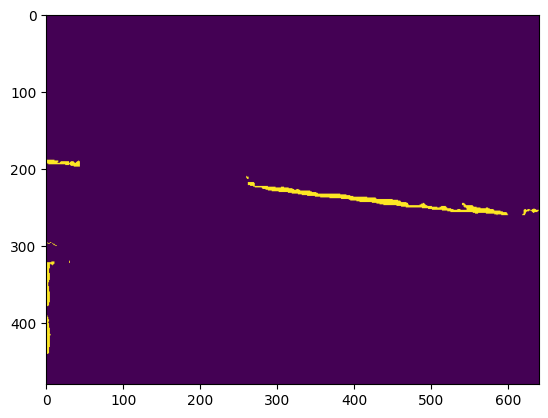

In [233]:
n = 299
plt.imshow(image1[n] == 1)

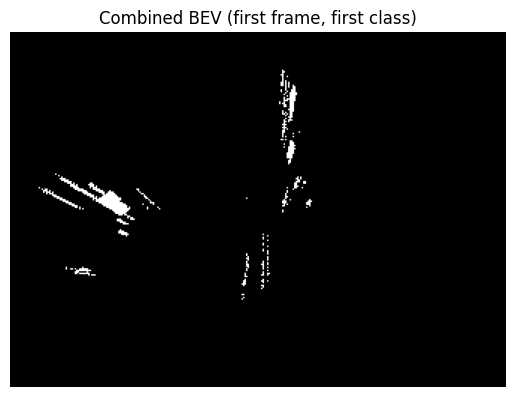

In [49]:
plt.imshow(combined[20,  ..., 0], cmap='gray')
plt.title("Combined BEV (first frame, first class)")
plt.axis('off')
plt.show()


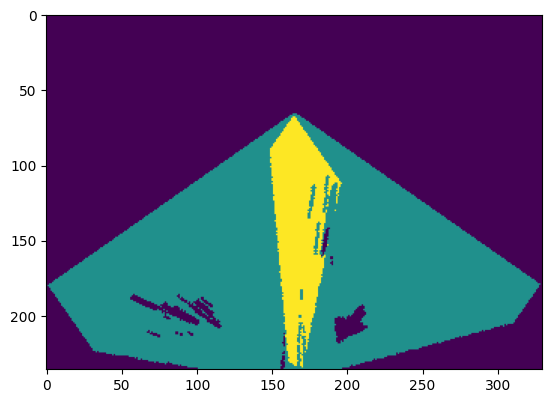

In [54]:
plt.imshow(combined_list[0])

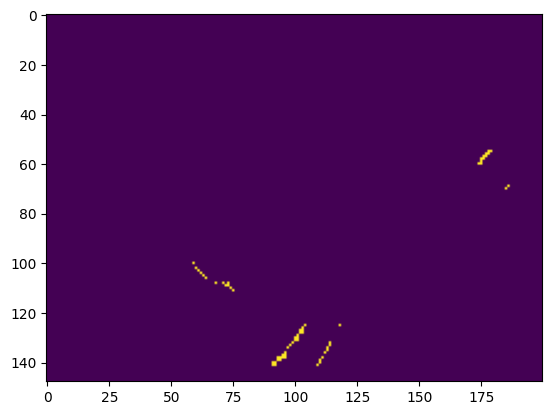

In [53]:
plt.imshow(bev1[50, :, :, 0])

In [41]:
com

NameError: name 'com' is not defined

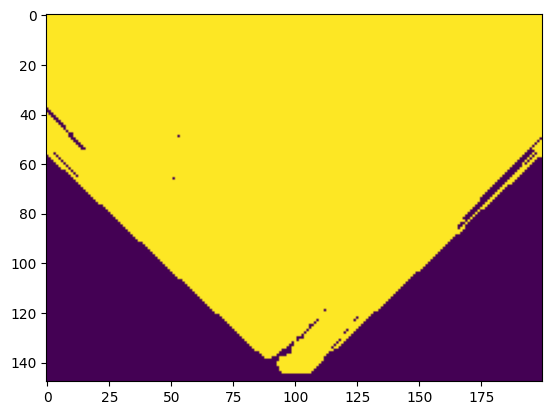

In [38]:
plt.imshow(bev_tensor1[:, :, 100])

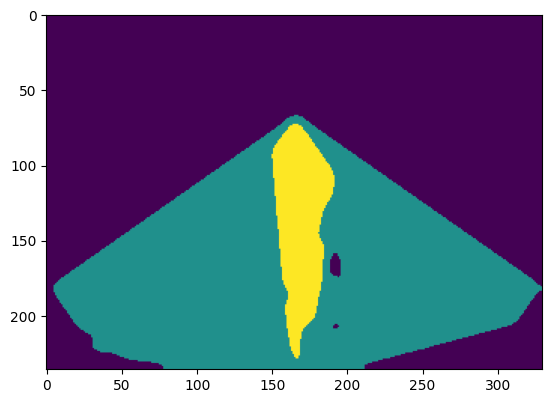

In [37]:
plt.imshow(dilate_erode_blur_slice(tensor_hwn, kernel_size=4, blur_sigma=6, blur_ksize=11)[:, :, 100])


In [198]:
import numpy as np
import cv2
from typing import Optional, Tuple
from dataclasses import dataclass

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src







def make_projector_and_grid(
    frame_shape: Tuple[int, int],          # (H, W) of your input npy frame
    *,
    fx: float = 1100.0,
    fy: Optional[float] = None,
    roll_deg: float = 0.0,
    pitch_deg_down: float = 6.0,
    yaw_deg: float = 0.0,
    height_m: float = 1.4,
    meters_per_pixel: float = 0.10,
    forward_range: Tuple[float, float] = (0.5, 40.0),
    lateral_range: Tuple[float, float] = (-8.0, 8.0),
) -> tuple:
    """Build and return (projector, grid) once, then reuse them for all frames."""
    H, W = frame_shape
    fy_loc = fx if fy is None else fy
    K = np.array([[fx,    0.0,  W / 2.0],
                  [0.0,  fy_loc, H / 2.0],
                  [0.0,   0.0,   1.0   ]], dtype=np.float64)

    roll  = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)   # down is negative in this convention
    yaw   = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m, roll=roll, pitch=pitch, yaw=yaw
    )
    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )
    return projector, grid


def npy_frame_to_bev(
    seg_frame: np.ndarray,                 # (H, W) labels or binary
    projector: "BEVProjector",
    grid: "BEVGrid",
    *,
    road_label: int = 0
) -> np.ndarray:
    """
    Use your BEVProjector/BEVGrid to warp a single npy frame to BEV.
    Returns uint8 BEV mask (H_out, W_out) with values {0,255}.
    """
    # Build 1/0 mask (road=1). If already binary uint8, just threshold.
    if seg_frame.dtype == np.uint8 and seg_frame.max() in (1, 255):
        mask01 = (seg_frame > 0).astype(np.uint8)
    else:
        mask01 = (seg_frame == road_label).astype(np.uint8)

    bev = projector.warp_calibrated(mask01=mask01, grid=grid)  # returns uint8 {0,255}
    return bev


seg = np.load('/workspace/test_results/cam2_1754410876.npy')[100]
projector, grid = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=380.0, fy=530.0,
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

bev = npy_frame_to_bev(seg, projector, grid, road_label=0)
# bev is (H_out, W_out) uint8 {0,255}



In [287]:
left_camera = np.load('/workspace/test_results/cam1_1754410876.npy')
right_camera = np.load('/workspace/test_results/cam2_1754410876.npy')


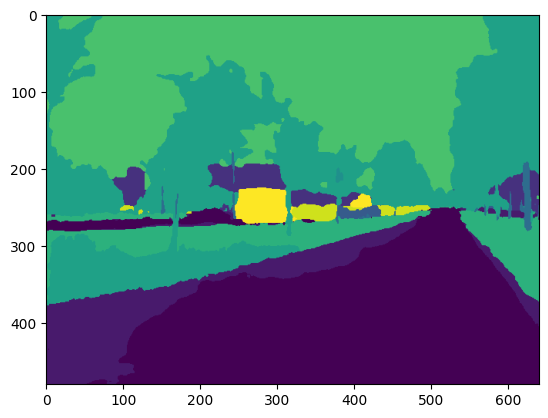

In [288]:
import matplotlib.pyplot as plt
plt.imshow(left_camera[150])

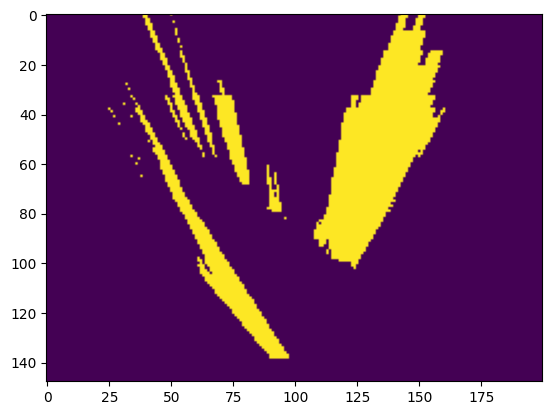

In [10]:
plt.imshow(bev_tensor2[:, :, 200])

In [221]:
t2v(denoised, "gray.mp4", fps=15, normalize=True)


In [439]:
flower_tensor_road = make_rotating_rect_tensor(H=236, W=330, n= 100, length=130, thickness=5)
flower_tensor_collision = make_rotating_rect_tensor(H=236, W=330, n= 100, length=60, thickness=5)

In [103]:
H, W, M = flower_tensor.shape

D = denoised[:, :, 40].astype(np.int64)       # or float64 / bool
F = flower_tensor.astype(np.int64)

# Method A: dot
dot_total = np.dot(D.reshape(1, -1), F.reshape(-1, M)).sum()

# Method B: broadcasted multiply
mul_total = (D[:, :, None] * F).sum()

print(dot_total, mul_total)  # should be equal now


70130 70130


In [101]:
(np.dot(denoised[:, :, 40].reshape(-1, 1).T, flower_tensor[:, :, :].reshape(-1, 250)).T).sum()

31986

In [124]:
# denoised: (H, W, N)
# flower_tensor: (H, W, M)
import time

time0 = time.time()
overlap_NM = np.sum(
    np.multiply(
        denoised[:, :, :, None],      # (H, W, N, 1)
        flower_tensor[:, :, None, :]  # (H, W, 1, M)
    ),
    axis=(0, 1)
)  # shape: (N, M)
print(time.time() - time0)

1.9135160446166992


In [722]:
import numpy as np

import numpy as np
import cv2

lista_ = []
lista__ = []
lista = []


def compute_overlap_per_frame_blurred(denoised: np.ndarray, 
        flower_tensor_road: np.ndarray, 
        flower_tensor_colision: np.ndarray, 
        collision_threshold: int = 180,
        ksize: int = 5, 
        sigma: float = 0,    
        top_percent: float = 5.0,      # e.g. 5 -> top 5% pixels
        top_threshold: float = 0.0,
        remembrance: float = 0,
        centre_bias_coefficient = 0.6
        ) -> np.ndarray:
    """
    Compute overlap between blurred `denoised` frames and all flower masks using np.multiply.
    
    Args:
        denoised: (H, W, N)
        flower_tensor: (H, W, M)
        ksize: kernel size for Gaussian blur (must be odd)
        sigma: standard deviation of the Gaussian kernel (0 = auto)

    Returns:
        overlap_NM: (N, M)
    """
    H, W, N = denoised.shape
    _, _, M = flower_tensor_road.shape

    overlap_NM = np.zeros((N, M), dtype=np.int32)
    list_of_chosen_roads = []
    centre_bias_array = decreasing_positive_quadratic(n=flower_tensor_road.shape[2], k = centre_bias_coefficient)

    sel_last = np.zeros((flower_tensor_road.shape[2], 1))

    for i in range(N):
        frame = denoised[:, :, i].astype(np.float32)


        convolved = np.sum(np.multiply(frame[:, :, None], flower_tensor_road), axis=(0, 1))
        # Apply Gaussian blur to the frame
        convolved_biased = np.multiply(convolved, centre_bias_array)
        lista.append(convolved_biased)

        blurred = gaussian_filter1d(convolved_biased, sigma=sigma).reshape(-1, 1)

        
        residual = (gaussian_filter1d(np.float32(sel_last)[:, 0], sigma=16) * remembrance).reshape(-1, 1)

        
        convolved_biased_ = np.multiply(blurred, (1 + residual)) 

        lista__.append(residual)
        #lista__.append(sel_last)

        
        lista_.append(convolved_biased_)
        


        cutoff = np.percentile(convolved_biased_, 100.0 - top_percent)
        
        
        sel = (convolved_biased_ >= cutoff) & (convolved_biased_ >= top_threshold)

        max_indicy = np.max(gaussian_filter1d(np.float16(sel[])))
        break

        sel_indices = np.where(sel[:, 0])[0] 


    


        

        reduced_flower_tensor_colision = flower_tensor_colision[:, :, sel[:, 0]]
        

        
        convolved_colision = np.sum(np.multiply(frame[:, :, None], reduced_flower_tensor_colision), axis=(0, 1))  
        
        valid_mask = convolved_colision >= collision_threshold
        valid_indices = sel_indices[valid_mask]



        selected_sum = flower_tensor_road[:, :, valid_indices].sum(axis=2) 
        
        list_of_chosen_roads.append(selected_sum)


        # Multiply blurred frame with all masks, then sum over H and W
        overlap_NM[i] = blurred[:, 0]

        sel_new = np.zeros_like(sel[:, 0], dtype=bool)
        sel_new[valid_indices] = True
        sel = sel_new[:, None]  
        sel_last = sel

        
    return overlap_NM, list_of_chosen_roads


import time

time0 = time.time()
overlap, roads = compute_overlap_per_frame_blurred(denoised, flower_tensor_road, flower_tensor_collision, ksize=5, sigma=4, top_percent=3, top_threshold=700, remembrance=8)
print("Elapsed:", time.time() - time0)

roads_tensor = list_to_numpy_tensor(roads)


t2v(roads_tensor, "roads" + current_image_path + str(time.time()) + ".mp4", fps=15)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3565685981.py, line 73)

<module 'numpy' from '/usr/local/lib/python3.10/dist-packages/numpy/__init__.py'>

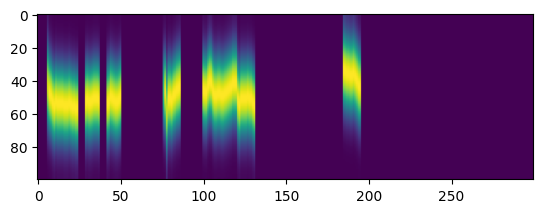

In [602]:
plt.imshow(list_to_numpy_tensor(lista__)[:, 0, :])


In [792]:
plt.plot(lista_[50])

IndexError: list index out of range

In [195]:
def compute_best_road_and_collision_viz(
    denoised: np.ndarray,                  # (H, W, N)
    flower_tensor_road: np.ndarray,        # (H, W, M_road)
    flower_tensor_collision: np.ndarray,   # (H, W, M_small)
    *,
    collision_threshold: int = 180,
    centre_bias_coefficient: float = 0.6,
    sigma_scores: float = 4.0,
    remembrance: float = 0.0,
    residual_sigma: float = 16.0,
    small_neighbour_sigma: float = 2.0,
    small_top_k: int = 1,
    road_color=(0, 255, 0),
    small_color=(0, 0, 255),
    convergent_with_road = 5,
    # thresholds:
    road_min_abs: float = 0.0,
    road_min_frac_of_max: float = 0.0,
    collision_min_abs: float = 0.0,
    collision_min_frac_of_max: float = 0.0,
    # NEW: highlight color for the single selected road
    selected_road_color=(0, 255, 255)
):
    """
    Returns:
        viz_tensor: (H, W, 3, N) uint8 visualization
        best_road_indices: (N,) int array of best road indices
        best_small_indices_per_frame: list of 1D arrays of small indices (length N)
    """
    H, W, N = denoised.shape
    _, _, M_road = flower_tensor_road.shape
    _, _, M_small = flower_tensor_collision.shape

    centre_bias_array = decreasing_positive_quadratic(n=M_road, k=centre_bias_coefficient).astype(np.float32)
    if centre_bias_array.ndim == 1:
        centre_bias_array = centre_bias_array
    else:
        centre_bias_array = centre_bias_array.reshape(-1)

    sel_last = np.zeros((M_road,), dtype=np.float32)

    viz_tensor = np.zeros((H, W, 3, N), dtype=np.uint8)
    best_road_indices = np.empty((N,), dtype=np.int32)
    best_small_indices_per_frame = []

    # helper: group contiguous angle indices (no wraparound)
    def _group_contiguous(idxs: np.ndarray):
        if idxs.size == 0:
            return []
        idxs = np.sort(idxs)
        groups = []
        start = idxs[0]
        prev = idxs[0]
        for x in idxs[1:]:
            if x == prev + 1:
                prev = x
            else:
                groups.append(np.arange(start, prev + 1))
                start = prev = x
        groups.append(np.arange(start, prev + 1))
        return groups

    for i in range(N):
        frame = denoised[:, :, i].astype(np.float32)

        # ---- ROAD (large tensor) ----
        road_scores = np.sum(frame[:, :, None] * flower_tensor_road.astype(np.float32), axis=(0, 1))
        road_scores *= centre_bias_array
        road_scores = gaussian_filter1d(road_scores, sigma=sigma_scores)

        if remembrance > 0.0:
            residual_smoothed = gaussian_filter1d(sel_last, sigma=residual_sigma)
            road_scores = road_scores * (1.0 + remembrance * residual_smoothed)

        best_road_idx = int(np.argmax(road_scores))
        best_road_indices[i] = best_road_idx

        road_gate = max(road_min_abs, road_min_frac_of_max * (float(road_scores.max()) if road_scores.size else 0.0))
        draw_road = bool(road_scores[best_road_idx] >= road_gate)

        sel_last = np.zeros_like(sel_last)
        sel_last[best_road_idx] = 1.0

        # ---- COLLISION (small tensor) ----
        small_scores = np.sum(frame[:, :, None] * flower_tensor_collision.astype(np.float32), axis=(0, 1))
        small_scores = gaussian_filter1d(small_scores, sigma=sigma_scores)

        bias = (1.0 + (road_scores / ((road_scores.sum() + 1e-8) * convergent_with_road)))
        small_scores_biased = small_scores * bias[:M_small] if bias.shape[0] != M_small else small_scores * bias

        coll_gate = max(
            collision_min_abs,
            collision_min_frac_of_max * (float(small_scores_biased.max()) if small_scores_biased.size else 0.0)
        )
        valid_small = np.where(small_scores_biased >= coll_gate)[0]

        if valid_small.size > 0:
            k = int(max(1, min(small_top_k, valid_small.size)))
            valid_scores = small_scores_biased[valid_small]
            sel = np.argpartition(-valid_scores, kth=k-1)[:k]
            best_small_idxs = valid_small[sel]
            best_small_idxs = best_small_idxs[np.argsort(-small_scores_biased[best_small_idxs])]
        else:
            best_small_idxs = np.array([], dtype=int)

        best_small_indices_per_frame.append(best_small_idxs)

        # ---- Visualization ----
        img = np.zeros((H, W, 3), dtype=np.uint8)

        # Keep ALL roads above threshold, but for each contiguous group keep ONLY the strongest angle,
        # and scale its intensity proportional to the group size (normalized by max group size).
        kept_indices = np.where(road_scores >= road_gate)[0]
        if kept_indices.size > 0:
            groups = _group_contiguous(kept_indices)
            max_len = max(len(g) for g in groups) if groups else 1
            base_col = np.array(road_color, dtype=np.float32)

            for g in groups:
                g = np.array(g, dtype=int)
                # strongest contender within the group
                g_best = g[np.argmax(road_scores[g])]
                best_mask = flower_tensor_road[:, :, g_best].astype(bool)

                # intensity ∝ group size (normalized)
                factor = 0.5 + 0.5 * (len(g) / max_len)  # in [0.5, 1.0]
                col = np.clip(np.round(base_col * factor), 0, 255).astype(np.uint8)

                img[best_mask] = col

        # Selected (global best) road overrides with a distinct color
        if draw_road:
            sel_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
            img[sel_mask] = selected_road_color

        # Small preferred directions on top (unchanged)
        if best_small_idxs.size > 0:
            if best_small_idxs.size == 1:
                small_mask = flower_tensor_collision[:, :, best_small_idxs[0]].astype(bool)
                img[small_mask] = small_color
            else:
                small_mask_union = np.any(flower_tensor_collision[:, :, best_small_idxs].astype(bool), axis=2)
                img[small_mask_union] = small_color

        viz_tensor[:, :, :, i] = img

    return viz_tensor, best_road_indices, best_small_indices_per_frame

time0 = time.time()

viz_tensor, best_road_indices, best_small_indices_per_frame = compute_best_road_and_collision_viz(
    denoised=denoised,
    flower_tensor_road=flower_tensor_road,
    flower_tensor_collision=flower_tensor_collision,
    centre_bias_coefficient=0.6,
    sigma_scores=4.0,
    remembrance=8,
    residual_sigma=16.0,
    small_neighbour_sigma=2.0,
    small_top_k=1,
    road_color=(100, 100, 0),
    small_color=(0, 0, 255),
    convergent_with_road=5,
    # thresholds:
    road_min_abs=40,
    road_min_frac_of_max=0.10,     # e.g., draw road only if >=10% of max score
    collision_min_abs=300,
    collision_min_frac_of_max=0.30 # e.g., keep small dirs >=30% of max biased score
)
print(time.time() - time0)


NameError: name 'flower_tensor_road' is not defined

In [943]:
# Save the RGB video
def help():
    viz_tensor, best_road_indices, best_small_indices_per_frame = compute_best_road_and_collision_viz(
        denoised=denoised,
        flower_tensor_road=flower_tensor_road,
        flower_tensor_collision=flower_tensor_collision,
        centre_bias_coefficient=0.6,
        sigma_scores=4.0,
        remembrance=8,
        residual_sigma=16.0,
        small_neighbour_sigma=2.0,
        small_top_k=1,
        road_color=(100, 100, 0),
        small_color=(0, 0, 255),
        convergent_with_road=5,
        # thresholds:
        road_min_abs=650,
        road_min_frac_of_max=0.10,     # e.g., draw road only if >=10% of max score
        collision_min_abs=300,
        collision_min_frac_of_max=0.30 # e.g., keep small dirs >=30% of max biased score
    )
    t2v(viz_tensor, "viz_" + current_image_path + str(time.time()) + ".mp4", fps=15)


In [961]:
t2v(viz_tensor, "viz_" + current_image_path + str(time.time()) + ".mp4", fps=15)

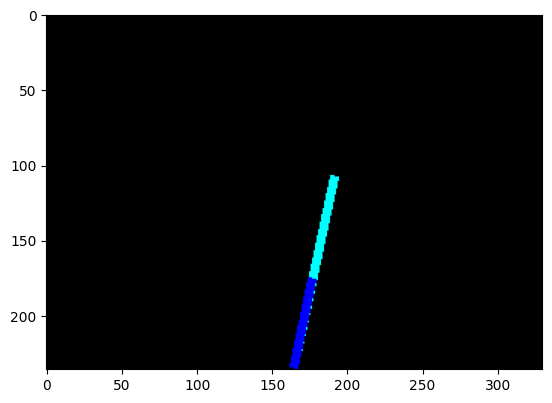

In [960]:
plt.imshow(viz_tensor[:, :, :, n])

In [196]:
import numpy as np
import cv2

def _angle_from_index(idx: int, M: int, start_deg=180.0, end_deg=0.0) -> float:
    # Assumes same angle sweep as make_rotating_rect_tensor: 180° -> 0°
    if M <= 1:
        return (start_deg + end_deg) * 0.5
    step = (end_deg - start_deg) / (M - 1)
    return start_deg + idx * step  # degrees

def _unit_dirs_from_angle_deg(theta_deg: float):
    # Consistent with your generator: dx=cos, dy=-sin (y down)
    th = np.deg2rad(theta_deg)
    dx = np.cos(th)
    dy = -np.sin(th)
    dir_vec = np.array([dx, dy], dtype=np.float32)
    left_n  = np.array([-dy, dx], dtype=np.float32)
    right_n = -left_n
    # normalize just in case
    for v in (dir_vec, left_n, right_n):
        n = np.linalg.norm(v) + 1e-8
        v /= n
    return dir_vec, left_n, right_n

def _rect_mask(H, W, p0, p1, thickness):
    # Filled rectangle defined by centerline p0->p1 and thickness
    p0 = np.asarray(p0, dtype=np.float32)
    p1 = np.asarray(p1, dtype=np.float32)
    v  = p1 - p0
    L  = np.linalg.norm(v) + 1e-8
    t  = thickness / 2.0
    n  = np.array([-v[1], v[0]], dtype=np.float32) / L  # normal unit
    poly = np.stack([
        p0 + n * t, p0 - n * t, p1 - n * t, p1 + n * t
    ]).astype(np.int32)
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)
    return mask

def _tiles_present_next_to_road(
    frame_bin: np.ndarray, region_mask: np.ndarray,
    grid_rc=(10,12), per_tile_min_sum=30, min_tiles=2
) -> bool:
    H, W = frame_bin.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)
    region_frame = (frame_bin & region_mask.astype(bool)).astype(np.uint8)

    cnt = 0
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]
            x0, x1 = xs[gj], xs[gj+1]
            tile_sum = int(region_frame[y0:y1, x0:x1].sum())
            if tile_sum >= per_tile_min_sum:
                cnt += 1
                if cnt >= min_tiles:
                    return True
    return False

def detect_crossroads_for_frame(
    frame: np.ndarray,                    # (H, W) binary-ish
    best_road_idx: int,
    flower_tensor_road: np.ndarray,       # (H, W, M_road) to infer angle/anchor
    *,
    # grid presence test
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    # geometric params
    road_anchor=(None, None),             # defaults to bottom-center if None
    anchor_frac_along_road=0.75,          # where along road the cross-arm starts [0..1]
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,           # try ± jitter around perfect 90°
    jitter_steps=3,                       # number of jitter samples each side
    # thresholds
    frame_bin_threshold=0.5,              # binarize frame
    side_min_abs=200,                     # min overlap to accept a side
    side_min_frac_of_max=0.25,            # relative to best candidate on that side
    # drawing colors
    left_color=(255, 255, 0),             # BGR yellow
    right_color=(255, 0, 0)               # BGR blue-ish red
):
    H, W, M_road = flower_tensor_road.shape
    I = (frame >= frame_bin_threshold).astype(np.uint8)

    # Angle from best road index
    theta_deg = _angle_from_index(best_road_idx, M_road, start_deg=180.0, end_deg=0.0)
    fwd, left_n, right_n = _unit_dirs_from_angle_deg(theta_deg)

    # Road anchor default: same as your generator (bottom-center)
    if road_anchor[0] is None or road_anchor[1] is None:
        x0, y0 = W // 2, H - 1
    else:
        x0, y0 = road_anchor

    # Estimate road length from the mask’s farthest point in that slice
    road_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
    ys, xs = np.nonzero(road_mask)
    if len(xs) == 0:
        # no road pixels? early return
        return False, False, np.zeros_like(I), np.zeros_like(I), 0.0, 0.0, np.zeros((H, W, 3), dtype=np.uint8)

    # Approximate far endpoint along forward direction
    # Take median of far band for robustness
    proj = (xs - x0) * fwd[0] + (ys - y0) * fwd[1]
    L_est = float(np.percentile(proj[proj > 0], 90)) if np.any(proj > 0) else 60.0
    p_anchor = np.array([x0, y0], dtype=np.float32) + fwd * (anchor_frac_along_road * L_est)

    # Build thin side "region bands" next to road to test tile presence
    band_len = max(30.0, side_length_px * 0.6)
    band_th  = max(10.0, side_thickness_px * 0.8)

    def band_mask(nvec):
        p1 = p_anchor + nvec * band_len
        return _rect_mask(H, W, p_anchor, p1, band_th)

    left_band  = band_mask(left_n)
    right_band = band_mask(right_n)

    left_tiles_ok  = _tiles_present_next_to_road(I, left_band,  grid_rc, per_tile_min_sum, min_tiles_required)
    right_tiles_ok = _tiles_present_next_to_road(I, right_band, grid_rc, per_tile_min_sum, min_tiles_required)

    # If no tiles present on a side, we skip fitting for that side
    # (per your spec: "if tiles are present next to the selected rectangle (road) try to fit…")
    def fit_side(nvec, do_fit: bool):
        if not do_fit:
            return np.zeros_like(I), 0.0, False
        # Jitter angles around perfect normal
        n_steps = max(1, int(jitter_steps))  # <-- use a local var, no assignment to outer name
        jitters = np.linspace(-side_angle_jitter_deg, side_angle_jitter_deg, n_steps).astype(np.float32)
    
        best_score = -1.0
        best_mask  = None
    
        base_ang = np.rad2deg(np.arctan2(-nvec[1], nvec[0]))  # invert y for consistency
        for a in jitters:
            th = np.deg2rad(base_ang + a)
            n = np.array([np.cos(th), -np.sin(th)], dtype=np.float32)
            p1 = p_anchor + n * side_length_px
            mask = _rect_mask(H, W, p_anchor, p1, side_thickness_px)
            score = float((mask * I).sum())
            if score > best_score:
                best_score = score
                best_mask = mask
    
        # Gate by absolute / fractional thresholds
        frac_gate = side_min_frac_of_max * (best_score if best_score > 0 else 0.0)
        gate = max(side_min_abs, frac_gate)
        ok = best_score >= gate
        return best_mask.astype(np.uint8), best_score, ok

    left_mask,  left_score,  left_ok  = fit_side(left_n,  left_tiles_ok)
    right_mask, right_score, right_ok = fit_side(right_n, right_tiles_ok)

    # Simple overlay for this frame
    img = np.zeros((H, W, 3), dtype=np.uint8)
    if left_ok:
        img[left_mask.astype(bool)] = left_color
    if right_ok:
        img[right_mask.astype(bool)] = right_color

    return left_ok, right_ok, left_mask, right_mask, left_score, right_score, img
import numpy as np
import cv2

def _angle_from_index(idx: int, M: int, start_deg=180.0, end_deg=0.0) -> float:
    if M <= 1:
        return (start_deg + end_deg) * 0.5
    step = (end_deg - start_deg) / (M - 1)
    return start_deg + idx * step  # degrees

def _unit_dirs_from_angle_deg(theta_deg: float):
    th = np.deg2rad(theta_deg)
    dx = np.cos(th); dy = -np.sin(th)
    dir_vec = np.array([dx, dy], dtype=np.float32)
    left_n  = np.array([-dy, dx], dtype=np.float32)
    right_n = -left_n
    for v in (dir_vec, left_n, right_n):
        v /= (np.linalg.norm(v) + 1e-8)
    return dir_vec, left_n, right_n

def _rect_mask(H, W, p0, p1, thickness):
    p0 = np.asarray(p0, dtype=np.float32); p1 = np.asarray(p1, dtype=np.float32)
    v  = p1 - p0; L = np.linalg.norm(v) + 1e-8
    n  = np.array([-v[1], v[0]], dtype=np.float32) / L
    t  = thickness / 2.0
    poly = np.stack([p0 + n*t, p0 - n*t, p1 - n*t, p1 + n*t]).astype(np.int32)
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)
    return mask

def _tiles_present_next_to_road(frame_bin: np.ndarray, region_mask: np.ndarray,
                                grid_rc=(10,12), per_tile_min_sum=30, min_tiles=2) -> bool:
    H, W = frame_bin.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)
    region_frame = (frame_bin & region_mask.astype(bool)).astype(np.uint8)
    cnt = 0
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]; x0, x1 = xs[gj], xs[gj+1]
            if int(region_frame[y0:y1, x0:x1].sum()) >= per_tile_min_sum:
                cnt += 1
                if cnt >= min_tiles: return True
    return False

def _ang_diff_deg(a_deg: float, b_deg: float) -> float:
    """Smallest absolute difference between two angles in degrees (0..180]."""
    d = (a_deg - b_deg + 180.0) % 360.0 - 180.0
    return abs(d)

def detect_crossroads_for_frame(
    frame: np.ndarray,                    # (H, W) binary-ish
    best_road_idx: int,
    flower_tensor_road: np.ndarray,       # (H, W, M_road)
    *,
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    road_anchor=(None, None),
    anchor_frac_along_road=0.75,
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,
    jitter_steps=3,
    frame_bin_threshold=0.5,
    side_min_abs=200,
    side_min_frac_of_max=0.25,
    left_color=(255, 255, 0),
    right_color=(255, 0, 0),
    # NEW: constraints
    y_min_frac=0.5,                 # only score pixels with y >= H*y_min_frac (bottom half by default)
    perp_tolerance_deg=20.0         # candidate must be within ±tolerance of 90° to the road
):
    H, W, M_road = flower_tensor_road.shape
    I = (frame >= frame_bin_threshold).astype(np.uint8)

    # Bottom-half mask (NEW)
    bottom_mask = np.zeros((H, W), dtype=np.uint8)
    bottom_mask[int(H * y_min_frac):, :] = 1

    # Road direction & normals
    theta_deg = _angle_from_index(best_road_idx, M_road, start_deg=180.0, end_deg=0.0)
    fwd, left_n, right_n = _unit_dirs_from_angle_deg(theta_deg)
    fwd_ang_deg = np.rad2deg(np.arctan2(-fwd[1], fwd[0]))

    # Anchor (default bottom-center)
    if road_anchor[0] is None or road_anchor[1] is None:
        x0, y0 = W // 2, H - 1
    else:
        x0, y0 = road_anchor

    road_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
    ys, xs = np.nonzero(road_mask)
    if len(xs) == 0:
        return False, False, np.zeros_like(I), np.zeros_like(I), 0.0, 0.0, np.zeros((H, W, 3), dtype=np.uint8)

    proj = (xs - x0) * fwd[0] + (ys - y0) * fwd[1]
    L_est = float(np.percentile(proj[proj > 0], 90)) if np.any(proj > 0) else 60.0
    p_anchor = np.array([x0, y0], dtype=np.float32) + fwd * (anchor_frac_along_road * L_est)

    band_len = max(30.0, side_length_px * 0.6)
    band_th  = max(10.0, side_thickness_px * 0.8)

    def band_mask(nvec):
        p1 = p_anchor + nvec * band_len
        return _rect_mask(H, W, p_anchor, p1, band_th)

    left_band  = band_mask(left_n)
    right_band = band_mask(right_n)

    left_tiles_ok  = _tiles_present_next_to_road(I, left_band,  grid_rc, per_tile_min_sum, min_tiles_required)
    right_tiles_ok = _tiles_present_next_to_road(I, right_band, grid_rc, per_tile_min_sum, min_tiles_required)

    def fit_side(nvec, do_fit: bool):
        if not do_fit:
            return np.zeros_like(I), 0.0, False
        n_steps = max(1, int(jitter_steps))
        jitters = np.linspace(-side_angle_jitter_deg, side_angle_jitter_deg, n_steps).astype(np.float32)

        best_score = -1.0
        best_mask  = None
        best_ang_ok = False

        base_ang = np.rad2deg(np.arctan2(-nvec[1], nvec[0]))  # angle of ideal normal (deg)
        for a in jitters:
            n_ang = base_ang + a
            # NEW: perpendicularity gate (difference from 90° wrt road direction)
            dev_from_perp = abs(90.0 - _ang_diff_deg(n_ang, fwd_ang_deg))
            if dev_from_perp > perp_tolerance_deg:
                continue  # reject angles not sufficiently perpendicular

            th = np.deg2rad(n_ang)
            n = np.array([np.cos(th), -np.sin(th)], dtype=np.float32)
            p1 = p_anchor + n * side_length_px
            mask = _rect_mask(H, W, p_anchor, p1, side_thickness_px)

            # NEW: score only in bottom region
            score = float((mask & bottom_mask & I).sum())

            if score > best_score:
                best_score = score
                best_mask  = mask
                best_ang_ok = True

        if best_mask is None or not best_ang_ok:
            return np.zeros_like(I), 0.0, False

        # Thresholding (unchanged)
        frac_gate = side_min_frac_of_max * (best_score if best_score > 0 else 0.0)
        gate = max(side_min_abs, frac_gate)
        ok = best_score >= gate

        # EXTRA: ensure mask centroid is in bottom half as well (robustness)
        if ok:
            ys_m, xs_m = np.nonzero(best_mask)
            if ys_m.size > 0 and float(ys_m.mean()) < H * y_min_frac:
                ok = False

        return best_mask.astype(np.uint8), best_score, ok

    left_mask,  left_score,  left_ok  = fit_side(left_n,  left_tiles_ok)
    right_mask, right_score, right_ok = fit_side(right_n, right_tiles_ok)

    img = np.zeros((H, W, 3), dtype=np.uint8)
    if left_ok:  img[left_mask.astype(bool)]  = left_color
    if right_ok: img[right_mask.astype(bool)] = right_color

    return left_ok, right_ok, left_mask, right_mask, left_score, right_score, img

def detect_crossroads_over_video(
    denoised: np.ndarray,                 # (H, W, N)
    best_road_indices: np.ndarray,        # (N,)
    flower_tensor_road: np.ndarray,       # (H, W, M_road)
    *,
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    anchor_frac_along_road=0.75,
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,
    jitter_steps=3,
    frame_bin_threshold=0.5,
    side_min_abs=200,
    side_min_frac_of_max=0.25,
    left_color=(255, 255, 0),
    right_color=(255, 0, 0),
    # NEW pass-throughs
    y_min_frac=0.5,
    perp_tolerance_deg=20.0
):
    H, W, N = denoised.shape
    viz_cross = np.zeros((H, W, 3, N), dtype=np.uint8)
    left_ok_arr  = np.zeros((N,), dtype=bool)
    right_ok_arr = np.zeros((N,), dtype=bool)
    left_scores  = np.zeros((N,), dtype=np.float32)
    right_scores = np.zeros((N,), dtype=np.float32)

    for i in range(N):
        l_ok, r_ok, l_mask, r_mask, l_sc, r_sc, img = detect_crossroads_for_frame(
            frame=denoised[:, :, i],
            best_road_idx=int(best_road_indices[i]),
            flower_tensor_road=flower_tensor_road,
            grid_rc=grid_rc,
            per_tile_min_sum=per_tile_min_sum,
            min_tiles_required=min_tiles_required,
            anchor_frac_along_road=anchor_frac_along_road,
            side_length_px=side_length_px,
            side_thickness_px=side_thickness_px,
            side_angle_jitter_deg=side_angle_jitter_deg,
            jitter_steps=jitter_steps,
            frame_bin_threshold=frame_bin_threshold,
            side_min_abs=side_min_abs,
            side_min_frac_of_max=side_min_frac_of_max,
            left_color=left_color,
            right_color=right_color,
            # NEW
            y_min_frac=y_min_frac,
            perp_tolerance_deg=perp_tolerance_deg
        )
        viz_cross[:, :, :, i] = img
        left_ok_arr[i]  = l_ok
        right_ok_arr[i] = r_ok
        left_scores[i]  = l_sc
        right_scores[i] = r_sc

    return viz_cross, left_ok_arr, right_ok_arr, left_scores, right_scores

# If you want a single combined overlay: draw your road/small-dir viz and blend crossroads:
combined = viz_tensor.copy()                  # (H, W, 3, N)
mask_cross_nonzero = (viz_cross.sum(axis=2, keepdims=True) > 0).astype(np.uint8)
combined = np.where(mask_cross_nonzero, viz_cross, combined)

# Save:
t2v(combined, "viz_with_crossroads.mp4", fps=15)


NameError: name 'viz_tensor' is not defined

In [820]:
t2v(tensor_hwn, "ukupan_viz.mp4", fps=15)


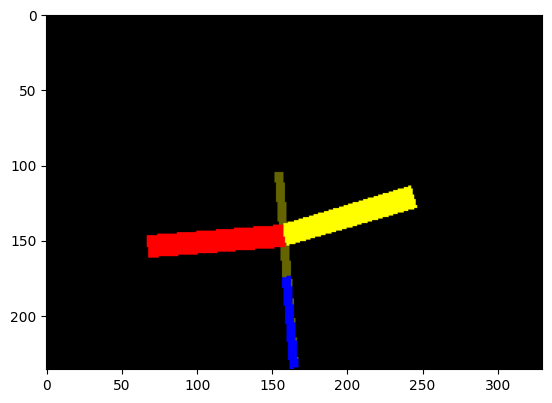

In [834]:
plt.imshow(combined[:, :, :, 100])

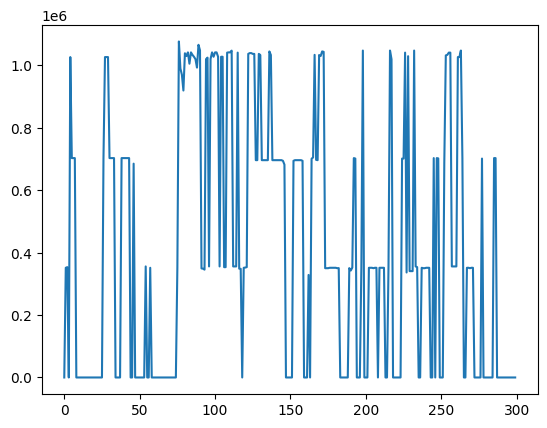

In [816]:
plt.plot(viz_cross.sum(axis = (0, 1, 2)))

In [9]:
import numpy as np

# Replace 'your_file.npy' with the actual file path
array2 = np.load("/workspace/test_results/cam1_1754410876.npy")



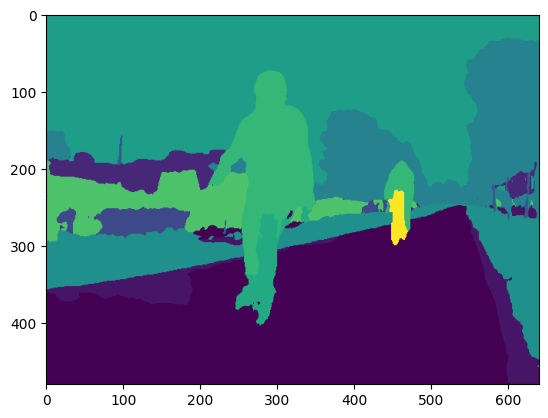

In [10]:
n = 270

plt.imshow(array2[n])

In [ ]:
cv2

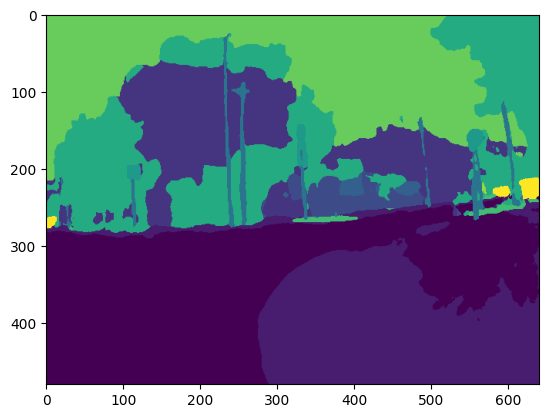

In [933]:
plt.imshow(array2[n])

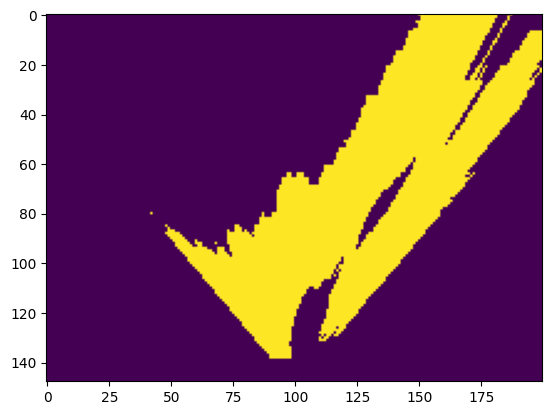

In [934]:
plt.imshow(bev_tensor2[:, :, n])

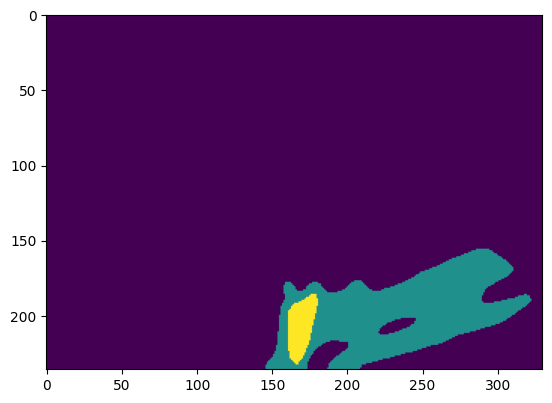

In [935]:
plt.imshow(denoised[:, :, n])

In [17]:
np.max(array2)

19

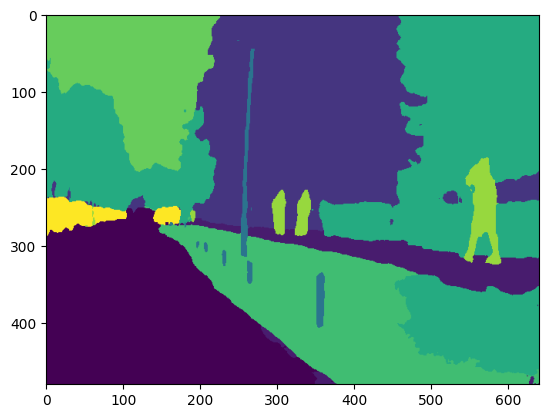

In [780]:
plt.imshow(array2[200])

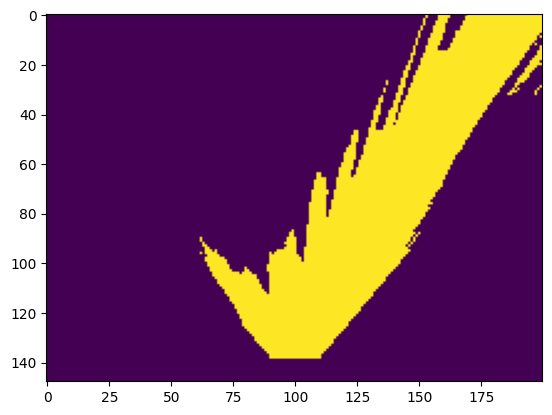

In [782]:
plt.imshow(bev_tensor2[:, :, 200])

In [284]:
import numpy as np
import cv2
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter1d

# ------------------ small utils ------------------


import numpy as np


import numpy as np

def make_oriented_road_image(
    h=256, w=256, *,
    angle_deg=0.0,
    cx=None, cy=None,
    bg_val=30, road_val=120, edge_val=190, dash_val=235,
    road_width_bottom=0.9, road_width_top=0.15,
    edge_thickness=2.0,
    dash_period=28.0, dash_duty=0.55,
    dash_scroll_px=0.0,           # increase over time: e.g. t * dash_speed_px
):
    if cx is None: cx = (w - 1) * 0.5
    if cy is None: cy = (h - 1) * 0.0   # <-- FIX: center vertically

    y, x = np.mgrid[0:h, 0:w].astype(np.float32)
    xd = x - cx
    yd = y - cy

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)

    xp =  xd * c + yd * s
    yp = -xd * s + yd * c

    yprime = yp + cy

    t  = np.clip(yprime / max(h - 1.0, 1.0), 0.0, 1.0)
    tb = 1.0 - t

    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w     = half_w_top + (half_w_bot - half_w_top) * tb

    dist = np.abs(xp)

    img = np.full((h, w), float(bg_val), dtype=np.float32)

    edge_soft = 0.6 + (1.6 - 0.6) * tb
    road_mask = 1.0 - np.clip((dist - half_w) / np.maximum(edge_soft, 1e-6), 0.0, 1.0)
    img = img * (1.0 - road_mask) + road_val * road_mask

    thick = 0.5 + (edge_thickness - 0.5) * tb
    edge_dist = np.abs(dist - half_w)
    edge_mask = np.exp(-(edge_dist**2) / (2.0 * (np.maximum(thick, 1e-6) ** 2)))
    img = img * (1.0 - edge_mask) + edge_val * edge_mask

    # --- moving dashes (scroll 'toward' the bottom when dash_scroll_px grows) ---
    center_thick = 0.5 + (2.2 - 0.5) * tb
    period = 10.0 + (dash_period - 10.0) * tb
    dash_len = dash_duty * period

    # Use a minus so increasing scroll moves dashes "down" in screen space
    phase = ((yprime - dash_scroll_px) / np.maximum(period, 1e-6)) % 1.0
    is_dash = (phase <= (dash_len / np.maximum(period, 1e-6))).astype(np.float32)

    centerline_profile = np.exp(-(dist**2) / (2.0 * (np.maximum(center_thick, 1e-6) ** 2)))
    centerline_mask = centerline_profile * is_dash * road_mask
    img = img * (1.0 - centerline_mask) + dash_val * centerline_mask

    return np.clip(img, 0, 255).astype(np.uint8)

# helper: alpha blend SRC(gray) over DST(rgb) using per-pixel alpha (0..1)
def blend_gray_over_rgb(dst_rgb_u8, src_gray_u8, alpha_f32):
    dst = dst_rgb_u8.astype(np.float32)
    src = src_gray_u8.astype(np.float32)
    a   = np.clip(alpha_f32[..., None], 0.0, 1.0)
    src_rgb = np.repeat(src[..., None], 3, axis=2)  # gray -> rgb
    out = src_rgb * a + dst * (1.0 - a)
    return np.clip(out, 0, 255).astype(np.uint8)



def make_rotating_rect_tensor(
    H=236, W=330, n=12, *,
    length=120,
    thickness=12
) -> np.ndarray:
    """
    Create a tensor of shape (H, W, n) with one filled rectangle per slice.
    The rectangle is anchored at the bottom-center and rotates from left to right.
    """
    assert n >= 2, "Need at least two layers to interpolate angles."
    T = np.zeros((H, W, n), dtype=np.uint8)

    x0, y0 = W // 2, H - 1  # Anchor at bottom-center

    for i in range(n):
        theta_deg = 180.0 - i * (180.0 / (n - 1))  # from 180° to 0°
        theta = np.deg2rad(theta_deg)

        # direction vector
        dx = np.cos(theta)
        dy = -np.sin(theta)  # image coords: y down → invert sin

        x1 = x0 + length * dx
        y1 = y0 + length * dy

        # normal vector for thickness
        nx = -dy
        ny = dx

        half_t = thickness / 2.0

        p0 = np.array([x0, y0], dtype=np.float32)
        p1 = np.array([x1, y1], dtype=np.float32)
        nvec = np.array([nx, ny], dtype=np.float32)

        polygon = np.stack([
            p0 + nvec * half_t,
            p0 - nvec * half_t,
            p1 - nvec * half_t,
            p1 + nvec * half_t
        ]).astype(np.int32)

        canvas = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(canvas, [polygon], 1)
        T[:, :, i] = canvas

    return T




def decreasing_positive_quadratic(n: int, k: float = 0.6) -> np.ndarray:
    """
    Center-heavy bias in [~(1-k), 1]. k in [0,1]. Peak at center.
    """
    t = np.linspace(-1.0, 1.0, max(1, int(n)), dtype=np.float32)
    bias = 1.0 - k * (t ** 2)
    return np.clip(bias, 0.0, 1.0)

def rotate_shift_sum(img1, img2, angle_deg=-35.0, hor_shift_px=-40):
    """
    Rotate img1 by +angle and shift LEFT (negative), rotate img2 by -angle and shift RIGHT (positive).
    Sum results on a canvas that fits both.
    Inputs can be 0/1 or 0..255 (H,W) or (H,W,1/3).
    Returns: float32 or uint8, shape (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Frames must have same size"
    H, W = img1.shape[:2]
    is_color = (img1.ndim == 3)
    C = img1.shape[2] if is_color else 1

    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    M1[0, 2] += hor_shift_px  # left if negative
    M2[0, 2] -= hor_shift_px  # right if negative above

    def corners_after(M):
        cs = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        cs_h = np.hstack([cs, ones])
        return (M @ cs_h.T).T

    c1 = corners_after(M1)
    c2 = corners_after(M2)
    allc = np.vstack([c1, c2])
    mn = np.floor(allc.min(axis=0)).astype(int)
    mx = np.ceil(allc.max(axis=0)).astype(int)
    out_W, out_H = (mx - mn)[0], (mx - mn)[1]

    shift_x, shift_y = -mn[0], -mn[1]
    M1[:, 2] += shift_x; M2[:, 2] += shift_x
    M1[1, 2] += shift_y; M2[1, 2] += shift_y

    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    w1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    w2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    S = w1 + w2
    return np.clip(S, 0, 255).astype(img1.dtype) if np.issubdtype(img1.dtype, np.integer) else S

def denoise_frame(frame_01: np.ndarray, kernel_size=4, blur_ksize=11, blur_sigma=6.0) -> np.ndarray:
    """
    Light morph + blur on a single 2D binary-ish frame (0/1 or 0/255). Returns uint8 in {0,255}.
    (Uses erode->dilate then Gaussian blur.)
    """
    img = (frame_01 > 0).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    er = cv2.erode(img, k)
    di = cv2.dilate(er, k)
    bl = cv2.GaussianBlur(di, (blur_ksize, blur_ksize), blur_sigma)
    return bl

def _group_contiguous(idxs: np.ndarray):
    if idxs.size == 0: return []
    idxs = np.sort(idxs)
    groups = []
    start = prev = idxs[0]
    for x in idxs[1:]:
        if x == prev + 1:
            prev = x
        else:
            groups.append(np.arange(start, prev + 1))
            start = prev = x
    groups.append(np.arange(start, prev + 1))
    return groups

def _resample_scores(scores: np.ndarray, out_len: int) -> np.ndarray:
    """Linear resample scores from len M_road to M_small to build a same-length bias."""
    M = len(scores)
    if M == out_len: return scores.copy()
    x_in = np.linspace(0, M - 1, M, dtype=np.float32)
    x_out = np.linspace(0, M - 1, out_len, dtype=np.float32)
    return np.interp(x_out, x_in, scores).astype(np.float32)

# ------------------ streaming state ------------------

@dataclass
class ProcessingState:
    """Carry temporal state between calls."""
    sel_last_road: np.ndarray | None = None   # (M_road,) one-hot smoothed memory
    last_best_road_idx: int | None = None


import numpy as np




# ------------------ per-frame processor ------------------

def process_two_bev_frames(
    cam1_bev: np.ndarray,                 # (H, W) 0/1 or 0/255
    cam2_bev: np.ndarray,                 # (H, W) same shape as cam1_bev
    t: int,
    current_bike_speed,
    flower_tensor_road: np.ndarray,       # (H, W, M_road) uint8/bool masks
    flower_tensor_collision: np.ndarray,  # (H, W, M_small)
    state: "ProcessingState" | None = None,
    *,
    # combine params:
    combine_angle_deg: float = -35.0,
    combine_hshift_px: int = -40,
    # scoring/smoothing:
    centre_bias_coefficient: float = 0.6,
    sigma_scores: float = 4.0,
    remembrance: float = 8.0,
    residual_sigma: float = 16.0,
    convergent_with_road: float = 5.0,
    # thresholds:
    road_min_abs: float = 40.0,
    road_min_frac_of_max: float = 0.10,
    collision_min_abs: float = 300.0,
    collision_min_frac_of_max: float = 0.30,
    small_top_k: int = 1,
    # visualization colors:
    road_color=(100, 255, 100),
    selected_road_color=(0, 255, 255),
    small_color=(0, 0, 255),
    # denoise params:
    morph_kernel: int = 4,
    blur_ksize: int = 11,
    blur_sigma: float = 6.0,
    # NEW: angles for each road index
    road_angles_deg: np.ndarray | None = None,   # shape (M_road,), degrees
    angle_span_deg: float = 90.0,                # used if road_angles_deg is None (spread)
    # NEW: road rendering params
    render_road_width_bottom: float = 0.9,
    render_road_width_top: float = 0.15,
    render_edge_thickness: float = 2.0,
    render_dash_period: float = 28.0,
    render_dash_duty: float = 0.55,
    render_bg_val: int = 20,
    render_road_val: int = 80,
    render_edge_val: int = 230,
    render_dash_val: int = 230,
    group_alpha_base: float = 0.40,       # base alpha for groups
    sel_alpha: float = 0.75               # alpha for selected road
):
    """
    Returns:
      viz_img:     (Hc, Wc, 3) uint8 visualization for this frame
      denoised_u8: (Hc, Wc)    uint8 denoised (morph+blur) image of the combined frame
      new_state:   ProcessingState for next call
      result:      dict with fields (best_road_idx, best_small_idxs, kept_indices, combined_frame, road_scores, small_scores_biased)
    """
    H, W, M_road = flower_tensor_road.shape
    _, _, M_small = flower_tensor_collision.shape

    # 1) Combine two BEV frames into one canvas
    f1 = (cam1_bev > 0).astype(np.uint8)
    f2 = (cam2_bev > 0).astype(np.uint8)
    combined = rotate_shift_sum(f2, f1, angle_deg=combine_angle_deg, hor_shift_px=combine_hshift_px)
    combined01 = (combined > 0).astype(np.uint8)

    # 2) Denoise
    den = denoise_frame(combined01, kernel_size=morph_kernel, blur_ksize=blur_ksize, blur_sigma=blur_sigma)
    denoised_u8 = den
    frame = (den > 0).astype(np.float32)

    # 3) Prepare/restore state
    if state is None or state.sel_last_road is None or len(state.sel_last_road) != M_road:
        sel_last = np.zeros((M_road,), dtype=np.float32)
    else:
        sel_last = state.sel_last_road.astype(np.float32)

    # 4) ROAD scores
    road_scores = np.sum(frame[:, :, None] * flower_tensor_road.astype(np.float32), axis=(0, 1))  # (M_road,)
    road_scores *= decreasing_positive_quadratic(M_road, centre_bias_coefficient).astype(np.float32)
    road_scores = gaussian_filter1d(road_scores, sigma=sigma_scores)

    if remembrance > 0.0:
        residual_smoothed = gaussian_filter1d(sel_last, sigma=residual_sigma)
        road_scores = road_scores * (1.0 + remembrance * residual_smoothed)

    best_road_idx = int(np.argmax(road_scores))
    road_gate = max(road_min_abs, road_min_frac_of_max * (float(road_scores.max()) if road_scores.size else 0.0))
    draw_road = bool(road_scores[best_road_idx] >= road_gate)

    # update memory (one-hot)
    sel_last[:] = 0.0
    sel_last[best_road_idx] = 1.0

    # 5) COLLISION scores
    small_scores = np.sum(frame[:, :, None] * flower_tensor_collision.astype(np.float32), axis=(0, 1))
    small_scores = gaussian_filter1d(small_scores, sigma=sigma_scores)
    road_scores_small = _resample_scores(road_scores, M_small)
    bias = 1.0 + (road_scores_small / (road_scores_small.sum() + 1e-8)) * convergent_with_road
    small_scores_biased = small_scores * bias

    coll_gate = max(collision_min_abs, collision_min_frac_of_max * (float(small_scores_biased.max()) if small_scores_biased.size else 0.0))
    valid_small = np.where(small_scores_biased >= coll_gate)[0]

    if valid_small.size > 0:
        k = int(max(1, min(small_top_k, valid_small.size)))
        valid_scores = small_scores_biased[valid_small]
        sel = np.argpartition(-valid_scores, kth=k-1)[:k]
        best_small_idxs = valid_small[sel]
        best_small_idxs = best_small_idxs[np.argsort(-small_scores_biased[best_small_idxs])]
    else:
        best_small_idxs = np.array([], dtype=int)

    # 6) Visualization with oriented road rendering
    # ---- angle lookup
    if road_angles_deg is None:
        # default: spread indices evenly over [-angle_span/2, +angle_span/2]
        start, stop = -angle_span_deg * 0.5, angle_span_deg * 0.5
        angles = np.linspace(start, stop, M_road, dtype=np.float32)
    else:
        assert len(road_angles_deg) == M_road, "road_angles_deg must have length M_road"
        angles = np.asarray(road_angles_deg, dtype=np.float32)

    viz_img = np.zeros((H, W, 3), dtype=np.uint8)

    # helper: alpha blend a solid color using a float alpha map (0..1)
    def blend_color(dst_rgb_u8, color_rgb_u8, alpha_f32):
        dst = dst_rgb_u8.astype(np.float32)
        col = np.asarray(color_rgb_u8, dtype=np.float32)[None, None, :]
        a = np.clip(alpha_f32[..., None], 0.0, 1.0)
        out = col * a + dst * (1.0 - a)
        return np.clip(out, 0, 255).astype(np.uint8)

    kept_indices = np.where(road_scores >= road_gate)[0]
    if kept_indices.size > 0:
        groups = _group_contiguous(kept_indices)
        max_len = max(len(g) for g in groups) if groups else 1

        for g in groups:
            g = np.array(g, dtype=int)
            # pick strongest index inside the group
            g_best = g[np.argmax(road_scores[g])]
            ang = float(angles[g_best])

            # render oriented road (grayscale 0..255)
            road_img = np.fliplr(make_oriented_road_image(
                H, W, angle_deg=ang,
                road_width_bottom=render_road_width_bottom,
                road_width_top=render_road_width_top,
                edge_thickness=render_edge_thickness,
                dash_period=render_dash_period,
                dash_duty=render_dash_duty,
                bg_val=render_bg_val,
                road_val=render_road_val,
                edge_val=render_edge_val,
                dash_val=render_dash_val,
                dash_scroll_px=t * current_bike_speed
            ))
            # use intensity above background as alpha (scaled by group length)
            alpha = (road_img.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
            alpha = np.clip(alpha, 0.0, 1.0)
            strength = 0.5 + 0.5 * (len(g) / max_len)   # [0.5..1.0]
            alpha *= (group_alpha_base * strength)

            viz_img = blend_color(viz_img, np.array(road_color, np.uint8), alpha)

    if draw_road:
        ang_sel = float(angles[best_road_idx])
        road_img_sel = np.fliplr(make_oriented_road_image(
            H, W, angle_deg=ang_sel,
            road_width_bottom=render_road_width_bottom,
            road_width_top=render_road_width_top,
            edge_thickness=render_edge_thickness,
            dash_period=render_dash_period,
            dash_duty=render_dash_duty,
            bg_val=render_bg_val,
            road_val=render_road_val,
            edge_val=render_edge_val,
            dash_val=render_dash_val,
            dash_scroll_px=t * current_bike_speed
        ))
        alpha_sel = (road_img_sel.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
        alpha_sel = np.clip(alpha_sel, 0.0, 1.0) * sel_alpha
        viz_img = blend_color(viz_img, np.array(selected_road_color, np.uint8), alpha_sel)

    # keep collision visualization as before (paint masks on top)
    if best_small_idxs.size > 0:
        small_rgb = np.array(small_color, dtype=np.uint8)
        if best_small_idxs.size == 1:
            small_mask = flower_tensor_collision[:, :, best_small_idxs[0]].astype(bool)
            viz_img[small_mask] = small_rgb
        else:
            small_mask_union = np.any(flower_tensor_collision[:, :, best_small_idxs].astype(bool), axis=2)
            viz_img[small_mask_union] = small_rgb

    # 7) Pack results & state
    new_state = ProcessingState(sel_last_road=sel_last.copy(), last_best_road_idx=best_road_idx)
    result = {
        "best_road_idx": best_road_idx,
        "best_small_idxs": best_small_idxs,
        "kept_indices": kept_indices,
        "combined_frame": combined01,
        "road_scores": road_scores,
        "small_scores_biased": small_scores_biased
    }

    return viz_img, denoised_u8, new_state, result





    
# one-time: build flower tensors (H, W must match your BEV frame after rotate/shift)
# flower_tensor_road  = make_rotating_rect_tensor(H, W, M_road, length=.., thickness=..)
# flower_tensor_collision = make_rotating_rect_tensor(H, W, M_small, length=.., thickness=..)
list_viz = []
list_denoised = []
list_combined = []


# --- imports you need here ---
import numpy as np
import cv2

# unchanged:
def combine_viz_and_denoised(viz_img: np.ndarray, denoised_frame: np.ndarray, alpha_viz: float = 0.85) -> np.ndarray:
    """
    Alpha-blend viz over denoised background only where viz has content.
    viz_img:       (H, W, 3) uint8
    denoised_frame:(H, W)    uint8
    returns:       (H, W, 3) uint8
    """
    bg = cv2.cvtColor(denoised_frame, cv2.COLOR_GRAY2BGR)
    mask = (viz_img.sum(axis=2) > 0)
    out = bg.copy()
    if mask.any():
        out[mask] = cv2.addWeighted(bg[mask], 1.0 - alpha_viz, viz_img[mask], alpha_viz, 0.0)
    return out

def render_roads_overlay(
    H, W,
    res,                    # dict returned by process_two_bev_frames
    angles_deg,             # np.ndarray shape (M_road,)
    t, bike_speed,          # motion params
    *,
    render_road_width_bottom=0.9,
    render_road_width_top=0.15,
    render_edge_thickness=2.0,
    render_dash_period=28.0,
    render_dash_duty=0.55,
    render_bg_val=30,
    render_road_val=120,
    render_edge_val=190,
    render_dash_val=235,
    group_alpha_base=0.40,
    sel_alpha=0.75
):
    road_scores     = res["road_scores"]
    kept_indices    = res["kept_indices"]
    best_road_idx   = int(res["best_road_idx"])
    road_gate       = max(0.0, 0.10 * float(road_scores.max()) if road_scores.size else 0.0)
    draw_road       = bool(road_scores[best_road_idx] >= road_gate)

    viz_img = np.zeros((H, W, 3), dtype=np.uint8)

    if kept_indices.size > 0:
        groups = _group_contiguous(kept_indices)
        max_len = max(len(g) for g in groups) if groups else 1
        for g in groups:
            g = np.asarray(g, dtype=int)
            g_best = g[np.argmax(road_scores[g])]
            ang = float(angles_deg[g_best])

            road_img = np.fliplr(np.flipud(make_oriented_road_image(
                H, W, angle_deg=ang,
                road_width_bottom=render_road_width_bottom,
                road_width_top=render_road_width_top,
                edge_thickness=render_edge_thickness,
                dash_period=render_dash_period,
                dash_duty=render_dash_duty,
                bg_val=render_bg_val,
                road_val=render_road_val,
                edge_val=render_edge_val,
                dash_val=render_dash_val,
                dash_scroll_px=float(t) * float(bike_speed)
            )))
            alpha = (road_img.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
            alpha = np.clip(alpha, 0.0, 1.0)
            alpha *= (group_alpha_base * (0.5 + 0.5 * (len(g) / max_len)))
            viz_img = blend_gray_over_rgb(viz_img, road_img, alpha)

    if draw_road:
        ang_sel = float(angles_deg[best_road_idx])
        road_img_sel = np.fliplr(np.flipud(make_oriented_road_image(
            H, W, angle_deg=ang_sel,
            road_width_bottom=render_road_width_bottom,
            road_width_top=render_road_width_top,
            edge_thickness=render_edge_thickness,
            dash_period=render_dash_period,
            dash_duty=render_dash_duty,
            bg_val=render_bg_val,
            road_val=render_road_val,
            edge_val=render_edge_val,
            dash_val=render_dash_val,
            dash_scroll_px=float(t) * float(bike_speed)
        )))
        alpha_sel = (road_img_sel.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
        alpha_sel = np.clip(alpha_sel, 0.0, 1.0) * sel_alpha
        viz_img = blend_gray_over_rgb(viz_img, road_img_sel, alpha_sel)

    return viz_img



# --- projectors (as you had) ---
projector_left, grid_left = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=300.0, fy=int(530/380*200),
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

projector_right, grid_right = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=380.0, fy=530.0,
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

# --- angle-indexed “flower” banks (as you had) ---
flower_tensor_road      = make_rotating_rect_tensor(H=236, W=330, n=100, length=130, thickness=5)
flower_tensor_collision = make_rotating_rect_tensor(H=236, W=330, n=100, length=60,  thickness=5)

# Build the angle grid for M_road directions (map index -> angle in degrees)
M_road  = flower_tensor_road.shape[2]
# Choose span you want to visualize (e.g., -60..+60 degrees); adjust as needed
road_angles_deg = np.linspace(-60.0, +60.0, M_road).astype(np.float32)

state = None

# --- init lists (make sure they exist) ---
list_viz, list_denoised, list_combined = [], [], []

for t in range(N):
    bev_frame_left  = npy_frame_to_bev(left_camera[t],  projector_left,  grid_left,  road_label=0)
    bev_frame_right = npy_frame_to_bev(right_camera[t], projector_right, grid_right, road_label=0)

    viz_img_dummy, denoised_frame, state, res = process_two_bev_frames(
        bev_frame_left, bev_frame_right, t, current_bike_speed=0,
        flower_tensor_road=flower_tensor_road,
        flower_tensor_collision=flower_tensor_collision,
        road_angles_deg=road_angles_deg,
        combine_angle_deg=-35.0, combine_hshift_px=40,
        render_road_width_bottom=0.15, render_road_width_top=0.10
    )

    H, W = denoised_frame.shape
    viz_gray = render_roads_overlay(H, W, res, road_angles_deg, t, bike_speed=-2.0,
                                    render_bg_val=30, render_road_val=120,
                                    render_edge_val=190, render_dash_val=235, render_road_width_bottom= 0.1, render_road_width_top=0.07)

    final_viz = combine_viz_and_denoised(viz_gray, denoised_frame)

    list_viz.append(viz_gray)
    list_denoised.append(denoised_frame)
    list_combined.append(final_viz)

viz_tensor      = np.stack(list_viz, axis=0)       # (N,H,W,3)
denoised_tensor = np.stack(list_denoised, axis=0)  # (N,H,W)
combined_tensor = np.stack(list_combined, axis=0)  # (N,H,W,3)


In [285]:
type(list_combined)

list

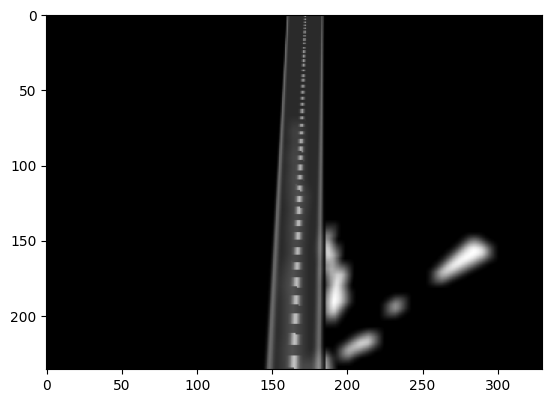

In [282]:
plt.imshow(list_combined[280])

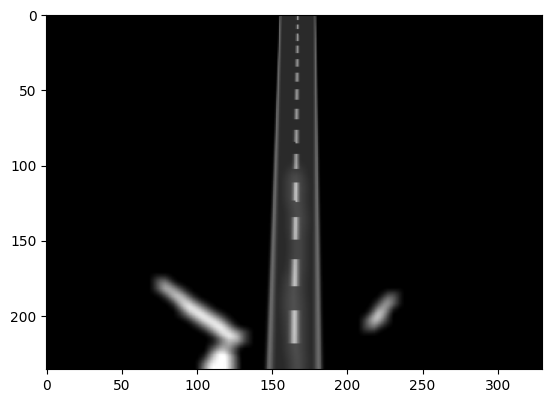

In [275]:
plt.imshow(list_combined[150])

In [30]:
seg.shape

(480, 640)

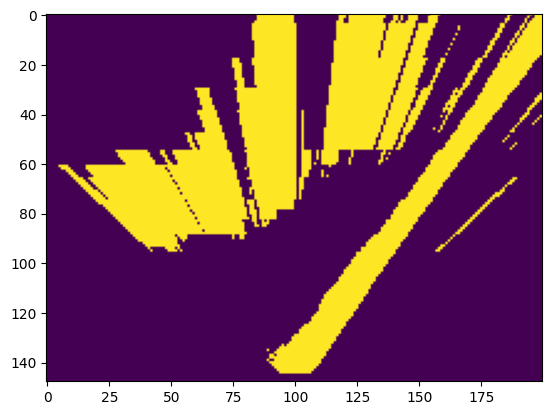

In [22]:
plt.imshow(left_frames_list[20])

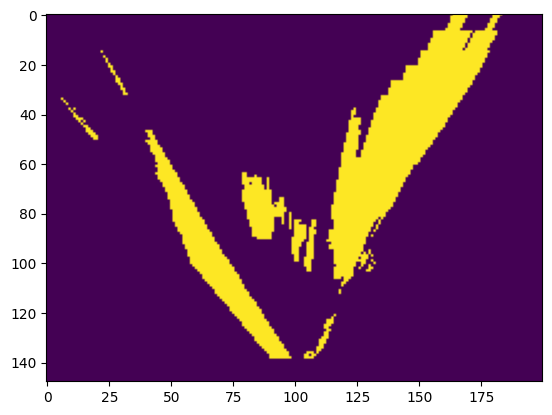

In [21]:
plt.imshow(right_frames_list[20])

In [286]:
t2v(list_to_numpy_tensor(list_combined), "put_lep.mp4")

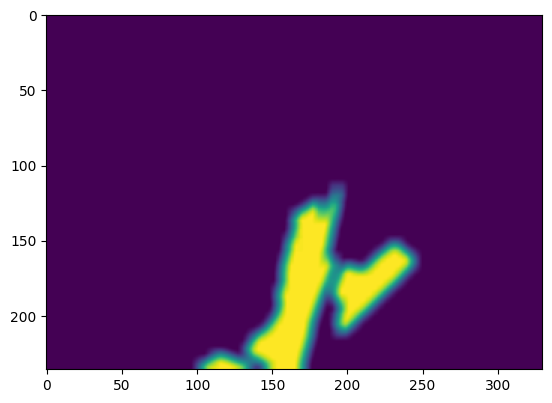

In [987]:
plt.imshow(list_denoised[200])

In [991]:
list_denoised[200].max()

255

In [753]:
np.argmax(viz_cross.sum(axis = (0, 1, 2)))

109

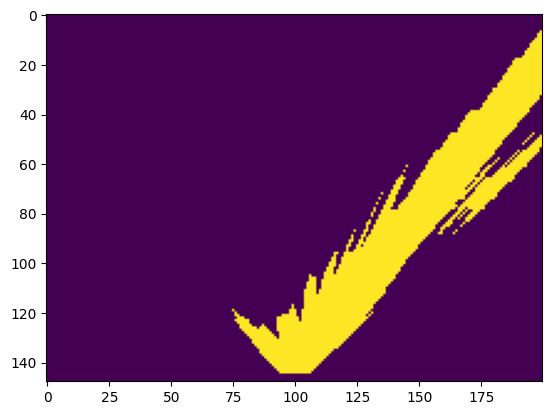

In [772]:
plt.imshow(bev_tensor1[:, :, 200])

In [744]:
plt.plot(gaussian_filter1d(lista__[50][: ,0], sigma=2))


IndexError: list index out of range

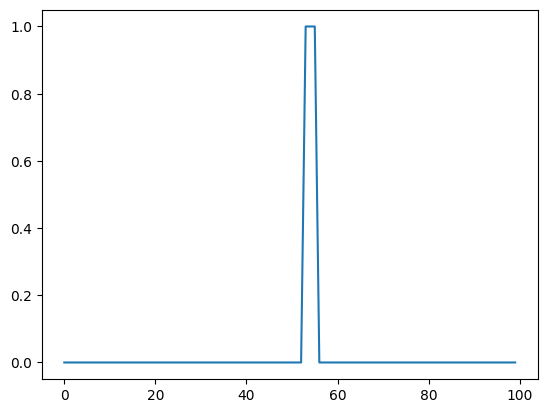

In [560]:
plt.plot(lista__[50][: ,0])

In [553]:
lista__[50].shape

(100, 1)

In [ ]:
roads_tensor.sum()

In [493]:
roads_tensor.sum()

166587

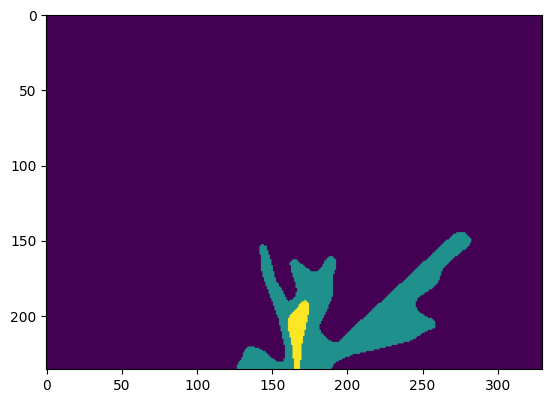

In [494]:
plt.imshow(denoised[:, :, 0])

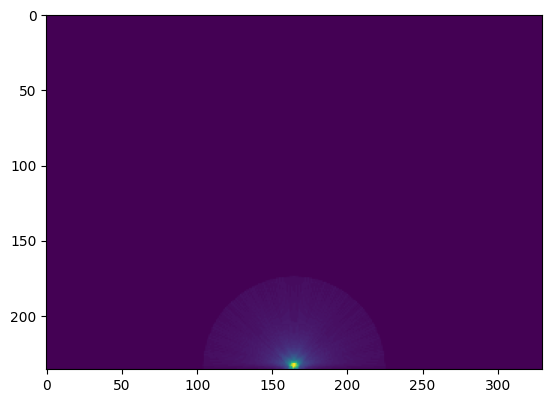

In [440]:
plt.imshow(flower_tensor_collision.sum(axis = 2))

In [346]:
np.sum(roads)

0

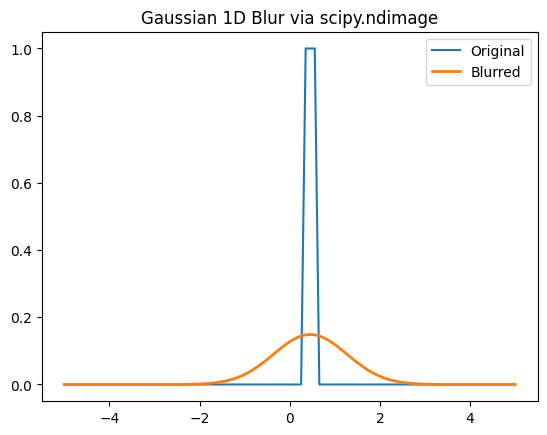

In [576]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt

# Sample signal
x = np.linspace(-5, 5, 100)
signal = np.float64(lista__[50])[:, 0]

#signal[50:52] = 1

# Apply Gaussian blur
blurred = gaussian_filter1d(signal, sigma=8)

# Plot
plt.plot(x, signal, label="Original")
plt.plot(x, blurred, label="Blurred", linewidth=2)
plt.legend()
plt.title("Gaussian 1D Blur via scipy.ndimage")
plt.show()

In [573]:
x.shape

(100,)

In [572]:
signal.shape

(100, 1)

In [294]:
flower_tensor.shape

(236, 330, 100)

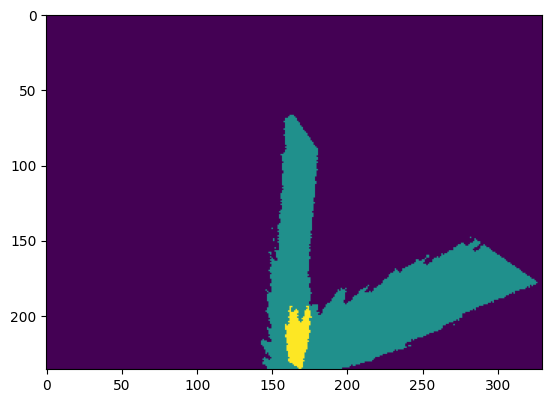

In [288]:
plt.imshow(tensor_hwn[:, :, n])

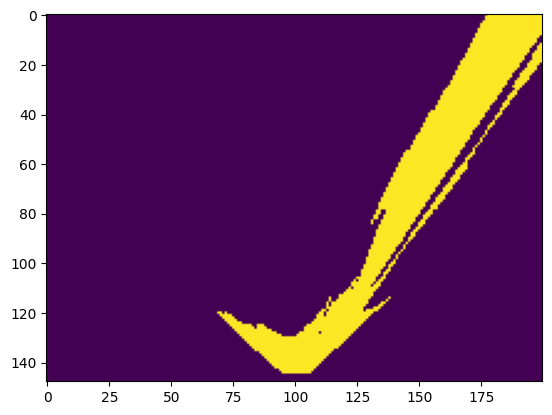

In [487]:
plt.imshow(bev_tensor1[:, :, 30])

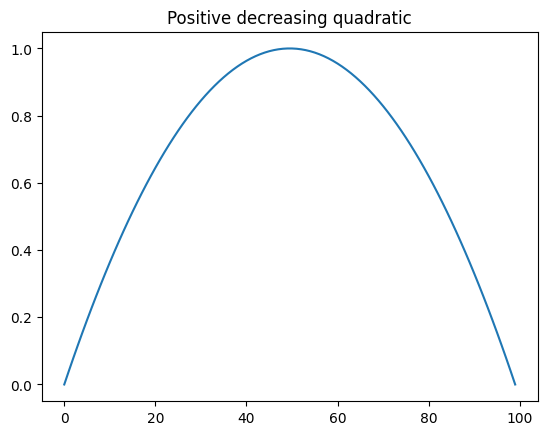

In [313]:
import numpy as np
import matplotlib.pyplot as plt

def decreasing_positive_quadratic(n=50, k=1):
    """
    Returns an array of length n representing a quadratic curve
    that is positive, centered, and strictly decreasing.
    """
    # Symmetric x around 0
    x = np.linspace(0, n, n)   # take only the left side
    y = ((-((x-(n/2)) / k)**2) + (n)**2) / n**2              # quadratic shifted up so it's always positive
    return y

arr = decreasing_positive_quadratic(100, k=0.5)


plt.plot(arr)
plt.title("Positive decreasing quadratic")
plt.show()


In [146]:
sel

NameError: name 'sel' is not defined

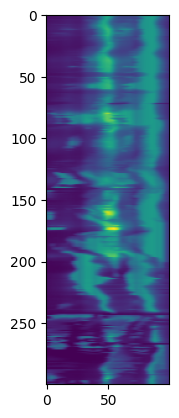

In [246]:
plt.imshow(overlap)

In [110]:
recon.sum()

0

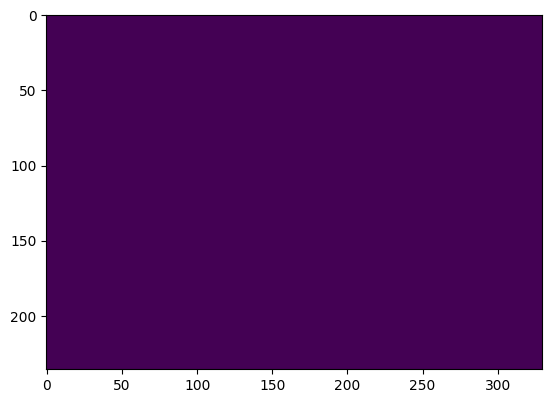

In [105]:
plt.imshow(recon[: ,:, 0])

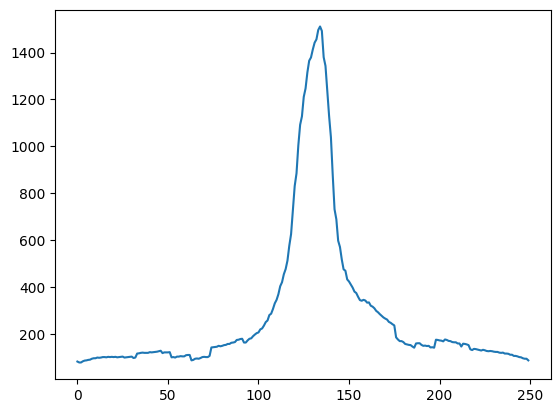

In [60]:
plt.plot(result)

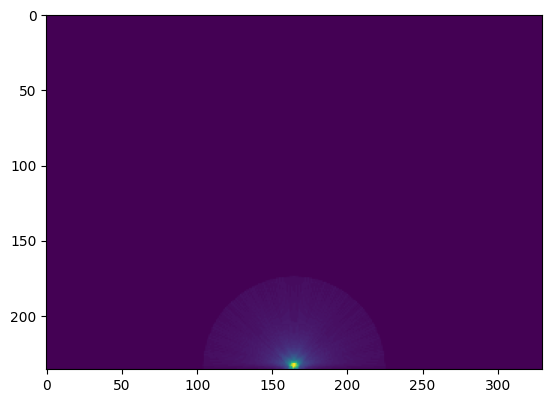

In [383]:
plt.imshow(flower_tensor.sum(axis = 2))

In [35]:
middle_square = np.zeros((236, 330))

In [36]:
middle_square[110:126, 158:172] = 1

In [40]:
np.multiply(middle_square, flower_tensor[:, :, 1]).sum()

0.0

In [33]:
result

array(63, dtype=uint8)

In [34]:
flower_tensor

array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]

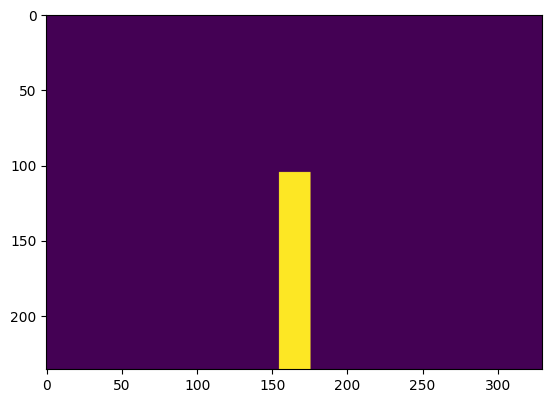

In [31]:
plt.imshow(flower_tensor[:, :, 2])

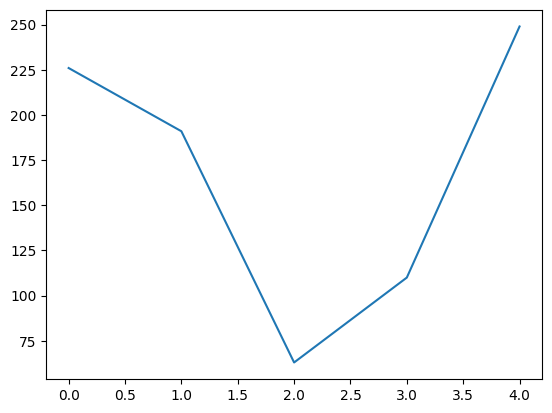

In [24]:
plt.plot(result)

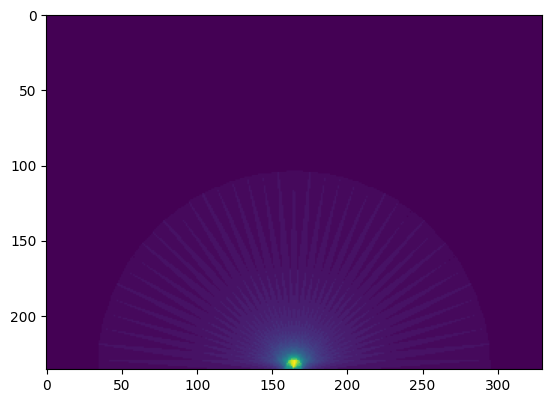

In [13]:
plt.imshow(flower_tensor.sum(axis = 2))

In [16]:
te.shape

(236, 330, 300)

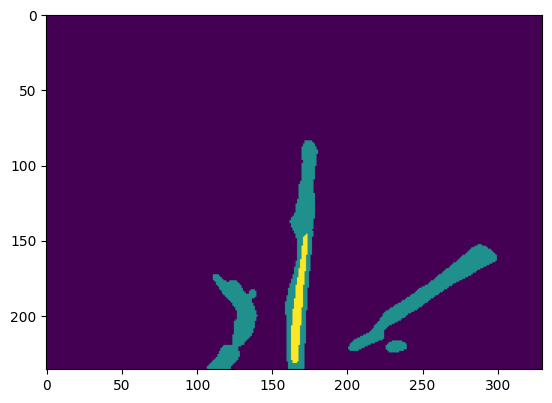

In [187]:
plt.imshow(denoised[:, :, 108])

In [62]:
np.max(tensor_hwn[:, :, 298])

2

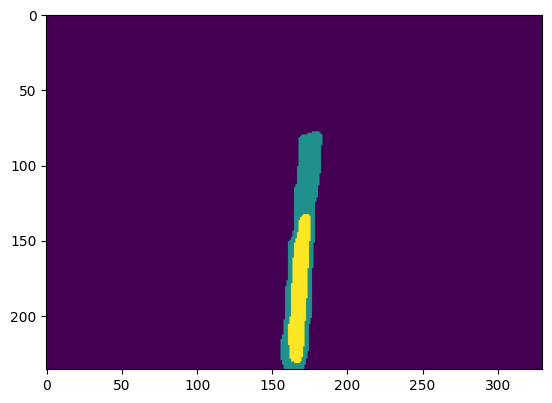

In [171]:
plt.imshow(denoised[:, :, 150])

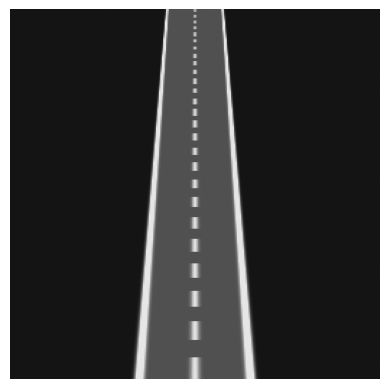

In [13]:
import numpy as np

def make_road_image(h=256, w=256,
                    road_width_bottom=0.3,   # fraction of image width at bottom
                    road_width_top=0.15,     # fraction of image width at top (vanishing)
                    edge_thickness=2,        # base thickness (pixels) at bottom; scales with perspective
                    dash_period=28,          # base dash+gap period at bottom; scales with perspective
                    dash_duty=0.55,          # fraction of period that is "dash" (rest is gap)
                    bg_val=20, road_val=80, edge_val=230, dash_val=230):
    """
    Returns a uint8 (h, w) array with a centered road, solid edges and dashed centerline.
    Grayscale intensities: bg_val < road_val < edge_val/dash_val for nice contrast.
    """

    y = np.arange(h)[:, None]                  # (h, 1)
    x = np.arange(w)[None, :]                  # (1, w)
    t = y / (h - 1.0)                          # 0 at top, 1 at bottom
    # We want widths defined as a function of 't' (top->bottom). Flip so 0=bottom,1=top is clearer:
    tb = 1.0 - t

    # Road half-width across rows, in pixels (linear taper from top to bottom)
    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w = half_w_top + (half_w_bot - half_w_top) * tb      # (h,1)

    # Road center is always w/2 (straight up the middle)
    cx = (w - 1) / 2.0

    # Distance from each pixel to the road center
    dist = np.abs(x - cx)

    # Base image: background
    img = np.full((h, w), bg_val, dtype=np.float32)

    # Soft edge for a slightly nicer look (antialiased boundary)
    # Transition width: small at the top, larger at the bottom
    edge_soft_top = 0.6
    edge_soft_bot = 1.6
    edge_soft = edge_soft_top + (edge_soft_bot - edge_soft_top) * tb

    # Smooth mask for road interior
    # mask ~ 1 inside road, ~0 outside, with soft transition
    road_mask = 1.0 - np.clip((dist - half_w) / np.maximum(edge_soft, 1e-6), 0, 1)
    img = img * (1 - road_mask) + road_val * road_mask

    # --- Lane edge lines (solid) ---
    # Thickness shrinks toward top
    thick_top = 0.5
    thick_bot = float(edge_thickness)
    thick = thick_top + (thick_bot - thick_top) * tb  # (h,1)

    # Left and right edge distances from the *edge* (not center)
    left_edge_dist  = np.abs(dist - half_w)
    right_edge_dist = left_edge_dist  # symmetric

    # Draw edges with a bright line (soft, so it blends nicely)
    edge_mask = np.exp(-(left_edge_dist**2) / (2*(np.maximum(thick,1e-6)**2))) \
              + np.exp(-(right_edge_dist**2) / (2*(np.maximum(thick,1e-6)**2)))
    edge_mask = np.clip(edge_mask, 0, 1)
    img = img * (1 - edge_mask) + edge_val * edge_mask

    # --- Center dashed line ---
    # The centerline thickness also shrinks toward top
    center_thick_top = 0.5
    center_thick_bot = 2.2
    center_thick = center_thick_top + (center_thick_bot - center_thick_top) * tb

    # Build a row-wise dash pattern with perspective: period shortens toward top
    period_top = 10.0
    period_bot = float(dash_period)
    period = period_top + (period_bot - period_top) * tb      # (h,1)
    dash_len = dash_duty * period                              # (h,1)

    # For each row, compute a repeating pattern along y (so dashes run along the road)
    # We'll use the actual row index 'y' but scale by "local" period to get perspective shortening.
    # Convert to continuous phase per-row: phase = y % period(row)
    # To vectorize, create a normalized "phase" by dividing y by period(row) and taking the fractional part.
    phase = (y / np.maximum(period, 1e-6)) % 1.0
    is_dash = (phase <= (dash_len / np.maximum(period,1e-6))).astype(np.float32)  # (h,1)

    # Centerline distance from the road center
    center_dist = dist

    # A soft, thin Gaussian centered at the road center; multiplied by dash mask and by being inside the road
    centerline_profile = np.exp(-(center_dist**2) / (2*(np.maximum(center_thick,1e-6)**2)))
    # Only draw centerline inside the road (use road_mask as limiter)
    centerline_mask = centerline_profile * is_dash * road_mask

    img = img * (1 - centerline_mask) + dash_val * centerline_mask

    # Clip and convert to uint8
    return np.clip(img, 0, 255).astype(np.uint8)

# Example usage:
if __name__ == "__main__":
    arr = np.flipud(make_road_image(256, 256))
    # Optional: visualize if you want
    # import matplotlib.pyplot as plt
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
    plt.axis('off'); plt.show()


/tmp/ipykernel_148/3413788071.py:59: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((arr * 255).astype(np.uint8), mode="RGBA")


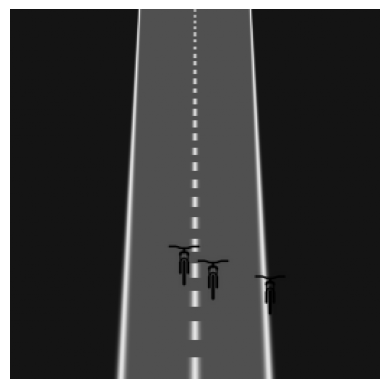

In [139]:
import numpy as np
from PIL import Image

# ---------------- Road generator (unchanged) ----------------
def make_road_image(h=256, w=256,
                    road_width_bottom=0.9, road_width_top=0.15,
                    edge_thickness=2, dash_period=28, dash_duty=0.55,
                    bg_val=20, road_val=80, edge_val=230, dash_val=230):
    y = np.arange(h)[:, None]
    x = np.arange(w)[None, :]
    t = y / (h - 1.0)
    tb = 1.0 - t

    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w = half_w_top + (half_w_bot - half_w_top) * tb
    cx = (w - 1) / 2.0
    dist = np.abs(x - cx)

    img = np.full((h, w), bg_val, dtype=np.float32)

    edge_soft = 0.6 + (1.6 - 0.6) * tb
    road_mask = 1.0 - np.clip((dist - half_w) / np.maximum(edge_soft, 1e-6), 0, 1)
    img = img * (1 - road_mask) + road_val * road_mask

    thick = 0.5 + (edge_thickness - 0.5) * tb
    edge_dist = np.abs(dist - half_w)
    edge_mask = np.exp(-(edge_dist**2) / (2*(np.maximum(thick,1e-6)**2)))
    img = img * (1 - edge_mask) + edge_val * edge_mask

    center_thick = 0.5 + (2.2 - 0.5) * tb
    period = 10.0 + (dash_period - 10.0) * tb
    dash_len = dash_duty * period
    phase = (y / np.maximum(period, 1e-6)) % 1.0
    is_dash = (phase <= (dash_len / np.maximum(period,1e-6))).astype(np.float32)
    centerline_profile = np.exp(-(dist**2) / (2*(np.maximum(center_thick,1e-6)**2)))
    centerline_mask = centerline_profile * is_dash * road_mask
    img = img * (1 - centerline_mask) + dash_val * centerline_mask

    return np.clip(img, 0, 255).astype(np.uint8)

# ---- Helper: compute road half-width per row (so we can scale sprite by lane width) ----
def compute_half_widths(h, w, road_width_bottom, road_width_top):
    y = np.arange(h)[:, None]
    t = y / (h - 1.0)
    tb = 1.0 - t
    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w = (half_w_top + (half_w_bot - half_w_top) * tb).astype(np.float32)  # (H,1)
    return half_w  # each row’s half width from center to edge

# ---------------- Sprites: load, resize, and alpha-compose ----------------
def load_rgba(path):
    im = Image.open(path).convert("RGBA")
    arr = np.asarray(im).astype(np.float32) / 255.0
    return arr

def resize_rgba(arr, new_h=None, new_w=None):
    im = Image.fromarray((arr * 255).astype(np.uint8), mode="RGBA")
    if new_h and not new_w:
        w = int(round(im.width * (new_h / im.height)))
        size = (w, new_h)
    elif new_w and not new_h:
        h = int(round(im.height * (new_w / im.width)))
        size = (new_w, h)
    else:
        size = (new_w, new_h)
    im = im.resize(size, Image.LANCZOS)
    return np.asarray(im).astype(np.float32) / 255.0

def alpha_over_gray(base_gray_u8, sprite_rgba_f32, top, left):
    H, W = base_gray_u8.shape
    sh, sw = sprite_rgba_f32.shape[:2]

    y0, x0 = max(0, top), max(0, left)
    y1, x1 = min(H, top + sh), min(W, left + sw)
    if y0 >= y1 or x0 >= x1:
        return base_gray_u8  # fully out of frame

    sy0, sx0 = y0 - top, x0 - left
    sy1, sx1 = sy0 + (y1 - y0), sx0 + (x1 - x0)

    base = base_gray_u8.astype(np.float32)
    spr = sprite_rgba_f32[sy0:sy1, sx0:sx1, :]  # (h,w,4)

    r, g, b, a = spr[..., 0], spr[..., 1], spr[..., 2], spr[..., 3]
    lum = 0.2126 * r + 0.7152 * g + 0.0722 * b  # grayscale sprite in [0,1]
    region = base[y0:y1, x0:x1]
    out_region = (lum * 255.0) * a + region * (1.0 - a)
    base[y0:y1, x0:x1] = out_region
    return np.clip(base, 0, 255).astype(np.uint8)

# ---------------- New: place icons at arbitrary filtered points ----------------
def place_icons_on_image(
    img_gray_u8,
    points,
    bike_path="bajs_ikonica.png",
    *,
    fixed_width_px=None,
    scale_by_lane=None,
    lane_scale=0.55,
    road_width_bottom=0.4,
    road_width_top=0.3,
):
    """
    Draw the bike icon at given points.

    Args:
      img_gray_u8: (H,W) uint8 grayscale road image.
      points: iterable of (y, x) integer coords. (icon bottom aligns to y, centered at x)
      bike_path: RGBA icon path.
      fixed_width_px: if set, use this exact icon width in px for all points.
      scale_by_lane: if True, scale icon width by lane width at each point's row using
                     road_width_bottom/top params (matches your generator).
      lane_scale: fraction of (full road width) to use as icon width, e.g. 0.55.
      road_width_bottom, road_width_top: used to compute lane width per row if scale_by_lane=True.

    Returns:
      New (H,W) uint8 image with icons rendered.
    """
    img = img_gray_u8.copy()
    H, W = img.shape
    sprite_orig = load_rgba(bike_path)

    # Precompute per-row road width if requested
    half_w = None
    if scale_by_lane:
        half_w = compute_half_widths(H, W, road_width_bottom, road_width_top)  # (H,1)

    for (y, x) in points:
        # Choose target sprite width
        if fixed_width_px is not None:
            target_w = int(max(8, round(fixed_width_px)))
        elif scale_by_lane:
            # Full road width at this row = 2*half_w[y]
            hw = float(half_w[min(max(int(y), 0), H-1), 0])
            target_w = int(max(8, round((2.0 * hw) * lane_scale)))
        else:
            # Fallback: reasonable default
            target_w = 48

        sprite = resize_rgba(sprite_orig, new_w=target_w)
        sh, sw = sprite.shape[:2]

        # Place so bottom sits at y and center at x
        top = int(round(y - sh))
        left = int(round(x - sw / 2.0))
        img = alpha_over_gray(img, sprite, top=top, left=left)

    return img

# ---------------- Convenience wrapper: generate road + place icons ----------------
def make_road_with_icons(
    points,
    h=256, w=256,
    bike_path="bajs_ikonica.png",
    road_width_bottom=0.4, road_width_top=0.3,
    use_lane_scaling=True, lane_scale=0.55, fixed_width_px=None
):
    """
    Creates a road image and renders the bike icon at each (y,x) in `points`.
    """
    img = np.flipud(make_road_image(h, w, road_width_bottom=road_width_bottom, road_width_top=road_width_top))
    img = place_icons_on_image(
        img, points, bike_path=bike_path,
        fixed_width_px=fixed_width_px,
        scale_by_lane=use_lane_scaling,
        lane_scale=lane_scale,
        road_width_bottom=road_width_bottom,
        road_width_top=road_width_top,
    )
    return img

# ---------------- Example ----------------
if __name__ == "__main__":
    # Example filtered points: list of (y, x)
    filtered_points = [(220, 180), (210, 140), (200, 120)]

    BIKE_PATH = "bajs_ikonica.png"
    img = make_road_with_icons(
        filtered_points,
        h=256, w=256,
        bike_path=BIKE_PATH,
        road_width_bottom=0.4, road_width_top=0.3,
        use_lane_scaling=True,   # scale icon based on lane width at each y
        lane_scale=0.55,         # 55% of lane width
        fixed_width_px=None      # or set to e.g. 48 to use fixed size
    )

    # Preview
    # import matplotlib.pyplot as plt
    plt.imshow(img, cmap='gray', vmin=0, vmax=255); plt.axis('off'); plt.show()
